In [1]:
import os
import mne
import numpy as np
# from sentry_sdk.utils import epoch
from sklearn.preprocessing import StandardScaler
import scipy.io as sio
from torch import optim
from typing import List
from torch.utils.data import DataLoader,TensorDataset
from sklearn.metrics import classification_report,confusion_matrix
import torch.nn as nn
import torch
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
def calculate_accuracy(loader:DataLoader,model:nn.Module,device:str)->float:
    correct = 0
    total = 0
    with torch.no_grad():
        for datas,labels in loader:
            datas,labels = datas.to(device),labels.to(device)
            outputs = model(datas)
            _,predicted = torch.max(outputs,1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

def get_losses(losses:List[float],loader:DataLoader,model:nn.Module,device:str)->List[float]:
    loss = 0
    with torch.no_grad():
        for i,(inputs,targets)in enumerate(loader):
            inputs,targets = inputs.to(device),targets.to(device)
            outputs = model(inputs)
            l = criterion(outputs,targets)
            loss += l.item()
        loss /= len(loader)
        losses.append(loss)
    return losses
def get_predictions(loader:DataLoader,model:nn.Module,device:str):
    all_targets = []
    all_predictions = []
    with torch.no_grad():
        for i ,(inputs,targets) in enumerate(loader):
            inputs,targets = inputs.to(device),targets.to(device)
            outputs = model(inputs)
            _,predicted = torch.max(outputs,1)
            all_targets.extend(targets.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())
    return all_targets,all_predictions

def loss_curve( epoches : int , train_losses : List[float],val_losses :List[float],model:str = '',folder_path = '',sub = '')->None:
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)
    plt.figure(figsize = (10,5))
    plt.plot(range(1,epoches +1),train_losses,label = 'Train Loss')
    plt.plot(range(1,epoches +1),val_losses,label = 'Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('loss')
    plt.title(f'Sub{sub+1} Training and Testing Loss Curve')
    plt.legend()
    img_path = os.path.join(folder_path,'loss_curve.png')
    plt.savefig(img_path)
    plt.show(block = False)
    plt.close()

def plot_confusion_matrix(
        all_train_targets:np.ndarray,
        all_train_predictions:np.ndarray,
        all_test_targets:np.ndarray,
        all_test_predictions:np.ndarray,
        model:str = '',
        folder_path ='',
        sub = ''
)->None:
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)

    plt.figure(figsize = (8,6))
    cm = confusion_matrix(all_train_targets,all_train_predictions)
    sns.heatmap(cm,annot = True,fmt = 'd',cmap = 'Blues',xticklabels = range(2),yticklabels = range(2))
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title(f'Sub{sub+1} Confusion Matrix-Train')
    plt.savefig(os.path.join(folder_path,f'Sub{sub+1} Confusion Matrix-Train'))
    plt.show(block = False)
    plt.close()

    plt.figure(figsize = (8,6))
    cm = confusion_matrix(all_test_targets,all_test_predictions)
    sns.heatmap(cm,annot = True,fmt = 'd',cmap = 'Blues',xticklabels =range(2),yticklabels = range(2))
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title(f'Sub{sub+1} Confusion Matrix-Test')
    plt.savefig(os.path.join(folder_path,f'Sub{sub+1} Confusion Matrix-Test'))
    plt.show(block = False)
    plt.close()

def print_Confusion_matrix(
        all_train_targets:np.ndarray,
        all_train_predictions:np.ndarray,
        all_test_targets:np.ndarray,
        all_test_predictions:np.ndarray,
        model:str = '',
        folder_path ='',
        sub = ''
):
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)

    report_train = classification_report(all_train_targets,all_train_predictions)
    report_test  = classification_report(all_test_targets, all_test_predictions)

    with open(os.path.join(folder_path,f'Sub{sub+1}Report.txt'),'w')as f:
        f.write('\nReport Train')
        f.write(report_train)
        f.write('\nReport Test')
        f.write(report_test)

In [4]:
import torch
import torch.nn as nn

class PatchEmbedding(nn.Module):
    """保持与之前一致的 EEGNet-style 前端"""
    def __init__(self, channels=17, samples=384, F1=16, D=2, F2=32,
                 kernelLength=32, kernelLength2=16, drop_out=0.5):
        super().__init__()
        self.F1 = F1
        self.D = D
        self.F2 = F2

        self.block1 = nn.Sequential(
            nn.Conv2d(1, F1, kernel_size=(1, kernelLength), stride=1,
                      padding=(0, kernelLength // 2), bias=False),
            nn.BatchNorm2d(F1)
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(F1, F1 * D, kernel_size=(channels, 1), groups=F1, bias=False),
            nn.BatchNorm2d(F1 * D),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 8)),
            nn.Dropout(p=drop_out)
        )

        self.block3 = nn.Sequential(
            nn.Conv2d(F1 * D, F2, kernel_size=(1, kernelLength2), stride=1,
                      padding=(0, kernelLength2 // 2), groups=F1 * D, bias=False),
            nn.Conv2d(F2, F2, kernel_size=(1, 1), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 16)),
            nn.Dropout(p=drop_out)
        )

    def forward(self, x):
        if len(x.shape) != 4:
            x = x.unsqueeze(1)  # (B, 1, C, T)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)      # (B, F2, 1, T_reduced)
        return x


class TransformerEncoderLayer(nn.Module):
    """保持不变"""
    def __init__(self, dim, heads=8, mlp_dim=512, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        residual = x
        x = self.norm1(x)
        attn_out, _ = self.attn(x, x, x)
        x = residual + attn_out

        residual = x
        x = self.norm2(x)
        x = residual + self.mlp(x)
        return x


class EEGViT(nn.Module):
    def __init__(self, n_classes=2, channels=17, samples=384,
                 drop_out=0.5, kernelLength=32, kernelLength2=16,
                 F1=16, D=2, F2=32,
                 vit_dim=256, vit_depth=6, vit_heads=8,
                 vit_mlp_dim=512, vit_dropout=0.1):
        super(EEGViT, self).__init__()

        self.patch_embed = PatchEmbedding(channels, samples, F1, D, F2,
                                          kernelLength, kernelLength2, drop_out)

        # 计算卷积后时间维度（精确计算）
        t_reduced = ((samples // 8) // 16)   # 384 → 3
        self.num_patches = t_reduced         # 每个时间步作为一个 patch
        self.patch_dim = F2                  # 每个 patch 的特征维度

        # 线性投影：将每个 patch 的 F2 维特征投影到 vit_dim
        self.proj = nn.Linear(self.patch_dim, vit_dim)

        # 可学习的位置编码和 CLS token
        self.cls_token = nn.Parameter(torch.randn(1, 1, vit_dim))
        self.pos_embed = nn.Parameter(torch.randn(1, self.num_patches + 1, vit_dim))

        # Transformer 编码器
        self.transformer = nn.ModuleList([
            TransformerEncoderLayer(vit_dim, vit_heads, vit_mlp_dim, vit_dropout)
            for _ in range(vit_depth)
        ])

        self.norm = nn.LayerNorm(vit_dim)

        # 分类头（与原 EEGNet 保持一致，使用 Softmax）
        self.classifier = nn.Sequential(
            nn.Linear(vit_dim, n_classes),
            nn.Softmax(dim=1)
        )

    def forward(self, x):
        # CNN 前端特征提取
        x = self.patch_embed(x)                     # (B, F2, 1, T_reduced)

        # 转为 patch 序列：(B, num_patches, patch_dim)
        B = x.shape[0]
        x = x.squeeze(2)                            # (B, F2, T_reduced)
        x = x.permute(0, 2, 1)                      # (B, T_reduced, F2)
        x = self.proj(x)                            # (B, T_reduced, vit_dim)

        # 添加 CLS token
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)       # (B, 1 + num_patches, vit_dim)

        # 添加位置编码
        x = x + self.pos_embed

        # Transformer 编码
        for layer in self.transformer:
            x = layer(x)

        x = self.norm(x)
        cls_output = x[:, 0]                        # 取 CLS token 输出

        # 分类
        out = self.classifier(cls_output)
        return out

In [5]:
import h5py
import numpy as np

# 读取文件
with h5py.File('seed.mat', 'r') as f:
    # 查看文件里有哪些键（可选）
    print("文件中的变量：", list(f.keys()))

    # 提取数据（注意 v7.3 文件里数组通常需要转置或额外处理）
    EEGsample = np.array(f['EEGsample'])
    subindex   = np.array(f['subindex'])
    substate   = np.array(f['substate'])
    EEGsample = EEGsample.transpose(2,1,0)
print("EEGsample shape:", EEGsample.shape)
print("subindex shape:", subindex.shape)
print("substate shape:", substate.shape)


文件中的变量： ['EEGsample', 'subindex', 'substate']
EEGsample shape: (11396, 17, 384)
subindex shape: (1, 11396)
substate shape: (1, 11396)


In [7]:
save_path = os.path.join(os.getcwd(), 'results')
if not os.path.exists(save_path):
    os.makedirs(save_path)

path = os.path.join(save_path, 'EEGVIT')
if not os.path.exists(path):
    os.makedirs(path)
report_path = os.path.join(path, 'report.txt')

torch.manual_seed(2024)


========== 开始第 1/22 折LOOCV（测试序号：0）==========
Fold [1/22], Epoch [1/500], Step [1/43], Loss: 0.6576
Fold [1/22], Epoch [1/500], Step [11/43], Loss: 0.6166
Fold [1/22], Epoch [1/500], Step [21/43], Loss: 0.6423
Fold [1/22], Epoch [1/500], Step [31/43], Loss: 0.6530
Fold [1/22], Epoch [1/500], Step [41/43], Loss: 0.6408
Fold [1/22], Epoch [101/500], Step [1/43], Loss: 0.4583
Fold [1/22], Epoch [101/500], Step [11/43], Loss: 0.4352
Fold [1/22], Epoch [101/500], Step [21/43], Loss: 0.4517
Fold [1/22], Epoch [101/500], Step [31/43], Loss: 0.4046
Fold [1/22], Epoch [101/500], Step [41/43], Loss: 0.4295
Fold [1/22], Epoch [201/500], Step [1/43], Loss: 0.4578
Fold [1/22], Epoch [201/500], Step [11/43], Loss: 0.4563
Fold [1/22], Epoch [201/500], Step [21/43], Loss: 0.4152
Fold [1/22], Epoch [201/500], Step [31/43], Loss: 0.4199
Fold [1/22], Epoch [201/500], Step [41/43], Loss: 0.4096
Fold [1/22], Epoch [301/500], Step [1/43], Loss: 0.3900
Fold [1/22], Epoch [301/500], Step [11/43], Loss: 0.4452

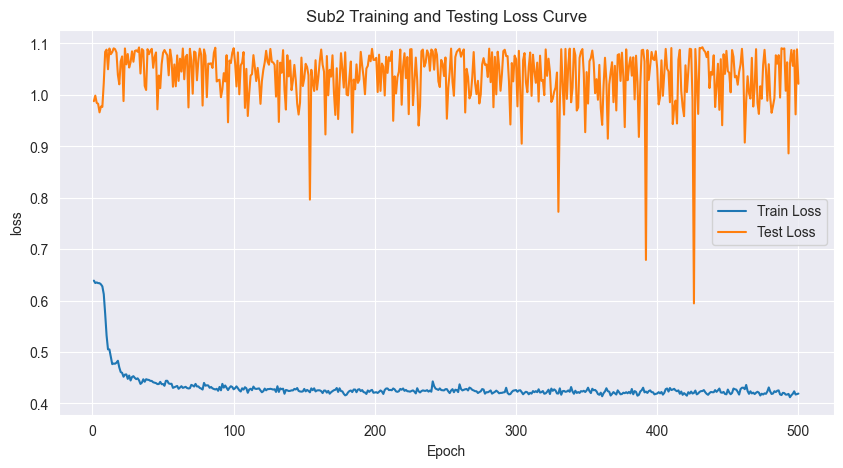

<Figure size 640x480 with 0 Axes>

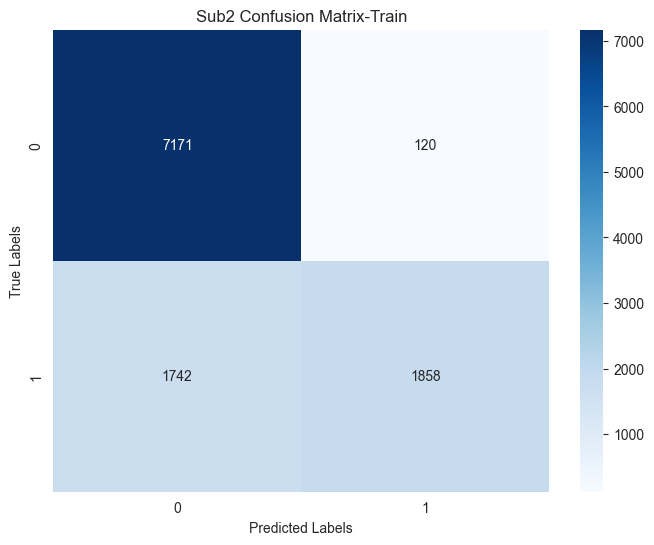

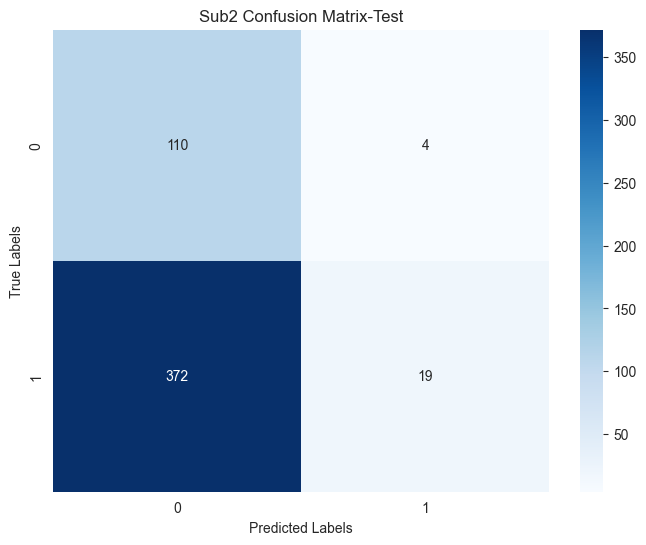

第 1 折（测试序号0）Acc: 25.54%

========== 开始第 2/22 折LOOCV（测试序号：1）==========
Fold [2/22], Epoch [1/500], Step [1/44], Loss: 0.7093
Fold [2/22], Epoch [1/500], Step [11/44], Loss: 0.6520
Fold [2/22], Epoch [1/500], Step [21/44], Loss: 0.6411
Fold [2/22], Epoch [1/500], Step [31/44], Loss: 0.6411
Fold [2/22], Epoch [1/500], Step [41/44], Loss: 0.6878
Fold [2/22], Epoch [101/500], Step [1/44], Loss: 0.4522
Fold [2/22], Epoch [101/500], Step [11/44], Loss: 0.4255
Fold [2/22], Epoch [101/500], Step [21/44], Loss: 0.4063
Fold [2/22], Epoch [101/500], Step [31/44], Loss: 0.4589
Fold [2/22], Epoch [101/500], Step [41/44], Loss: 0.4528
Fold [2/22], Epoch [201/500], Step [1/44], Loss: 0.4390
Fold [2/22], Epoch [201/500], Step [11/44], Loss: 0.4291
Fold [2/22], Epoch [201/500], Step [21/44], Loss: 0.4360
Fold [2/22], Epoch [201/500], Step [31/44], Loss: 0.4715
Fold [2/22], Epoch [201/500], Step [41/44], Loss: 0.4149
Fold [2/22], Epoch [301/500], Step [1/44], Loss: 0.4379
Fold [2/22], Epoch [301/500], St

<Figure size 640x480 with 0 Axes>

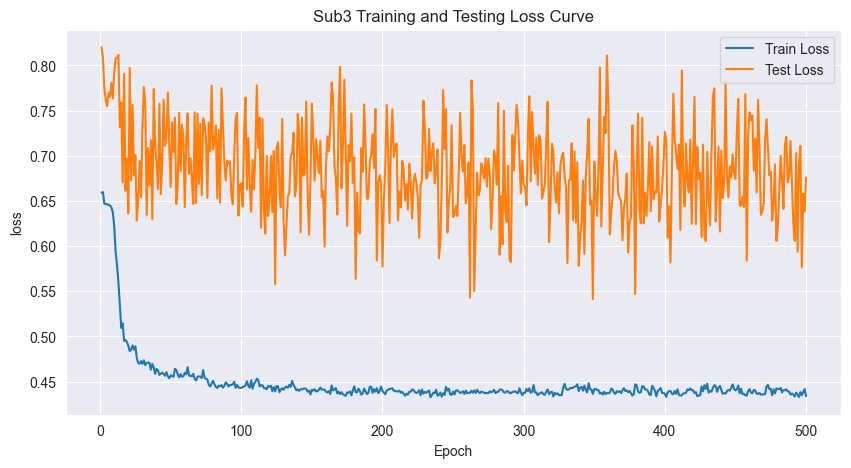

<Figure size 640x480 with 0 Axes>

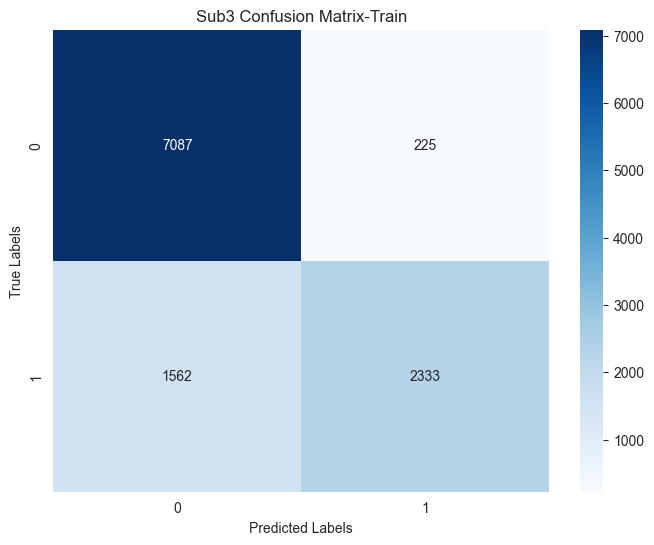

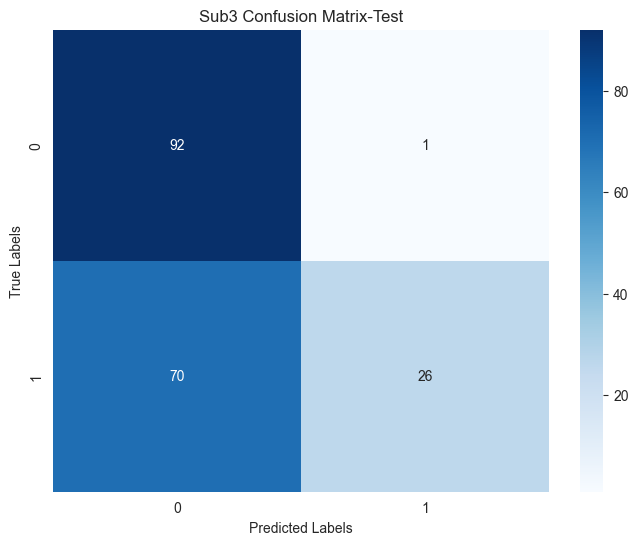

第 2 折（测试序号1）Acc: 62.43%

========== 开始第 3/22 折LOOCV（测试序号：2）==========
Fold [3/22], Epoch [1/500], Step [1/43], Loss: 0.6683
Fold [3/22], Epoch [1/500], Step [11/43], Loss: 0.6575
Fold [3/22], Epoch [1/500], Step [21/43], Loss: 0.6252
Fold [3/22], Epoch [1/500], Step [31/43], Loss: 0.6811
Fold [3/22], Epoch [1/500], Step [41/43], Loss: 0.6520
Fold [3/22], Epoch [101/500], Step [1/43], Loss: 0.4543
Fold [3/22], Epoch [101/500], Step [11/43], Loss: 0.4709
Fold [3/22], Epoch [101/500], Step [21/43], Loss: 0.5438
Fold [3/22], Epoch [101/500], Step [31/43], Loss: 0.4807
Fold [3/22], Epoch [101/500], Step [41/43], Loss: 0.4715
Fold [3/22], Epoch [201/500], Step [1/43], Loss: 0.4524
Fold [3/22], Epoch [201/500], Step [11/43], Loss: 0.4277
Fold [3/22], Epoch [201/500], Step [21/43], Loss: 0.4591
Fold [3/22], Epoch [201/500], Step [31/43], Loss: 0.4250
Fold [3/22], Epoch [201/500], Step [41/43], Loss: 0.4603
Fold [3/22], Epoch [301/500], Step [1/43], Loss: 0.4753
Fold [3/22], Epoch [301/500], St

<Figure size 640x480 with 0 Axes>

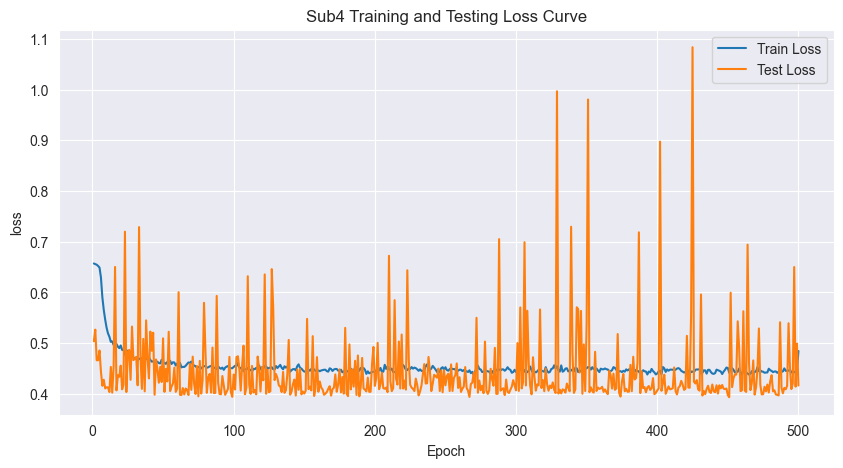

<Figure size 640x480 with 0 Axes>

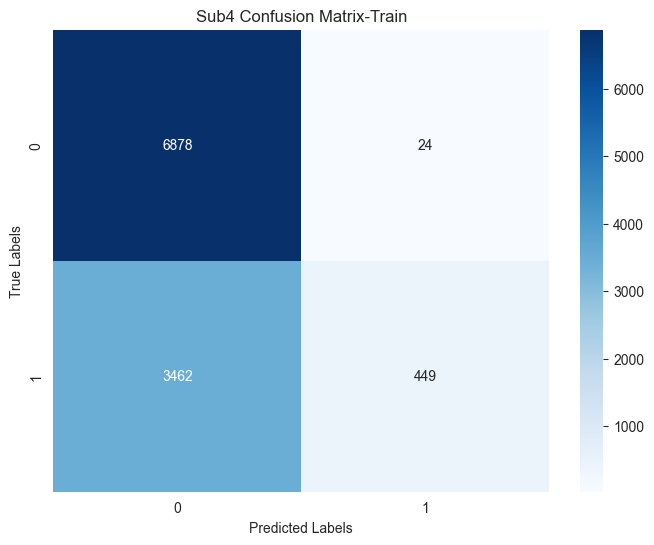

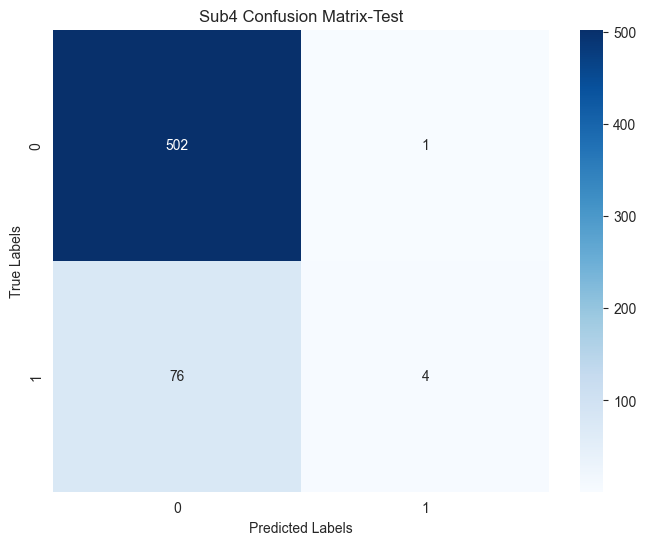

第 3 折（测试序号2）Acc: 86.79%

========== 开始第 4/22 折LOOCV（测试序号：3）==========
Fold [4/22], Epoch [1/500], Step [1/43], Loss: 0.7007
Fold [4/22], Epoch [1/500], Step [11/43], Loss: 0.5982
Fold [4/22], Epoch [1/500], Step [21/43], Loss: 0.6177
Fold [4/22], Epoch [1/500], Step [31/43], Loss: 0.7111
Fold [4/22], Epoch [1/500], Step [41/43], Loss: 0.6332
Fold [4/22], Epoch [101/500], Step [1/43], Loss: 0.4311
Fold [4/22], Epoch [101/500], Step [11/43], Loss: 0.4297
Fold [4/22], Epoch [101/500], Step [21/43], Loss: 0.4015
Fold [4/22], Epoch [101/500], Step [31/43], Loss: 0.4423
Fold [4/22], Epoch [101/500], Step [41/43], Loss: 0.4262
Fold [4/22], Epoch [201/500], Step [1/43], Loss: 0.4102
Fold [4/22], Epoch [201/500], Step [11/43], Loss: 0.4573
Fold [4/22], Epoch [201/500], Step [21/43], Loss: 0.4392
Fold [4/22], Epoch [201/500], Step [31/43], Loss: 0.4879
Fold [4/22], Epoch [201/500], Step [41/43], Loss: 0.4756
Fold [4/22], Epoch [301/500], Step [1/43], Loss: 0.4199
Fold [4/22], Epoch [301/500], St

<Figure size 640x480 with 0 Axes>

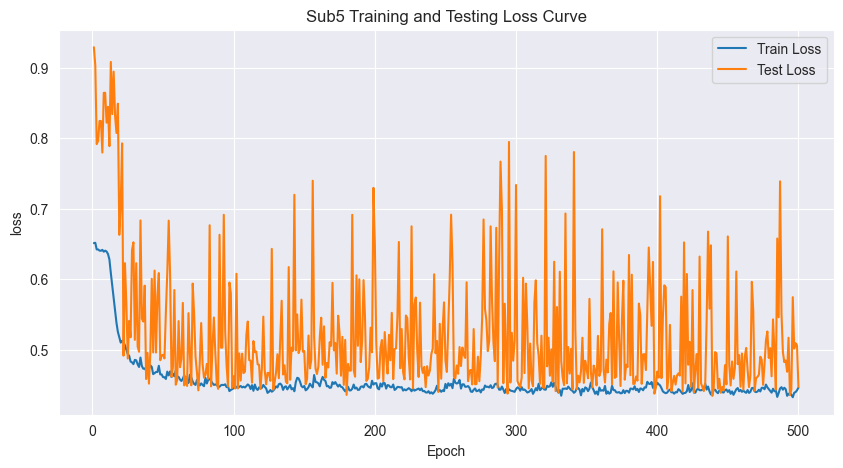

<Figure size 640x480 with 0 Axes>

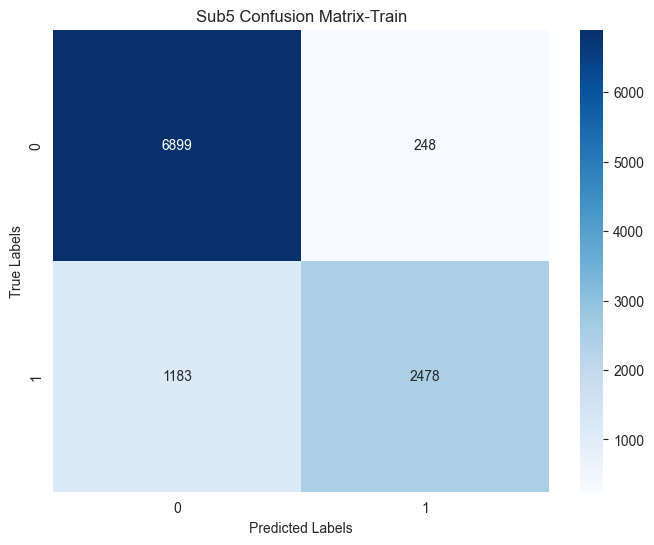

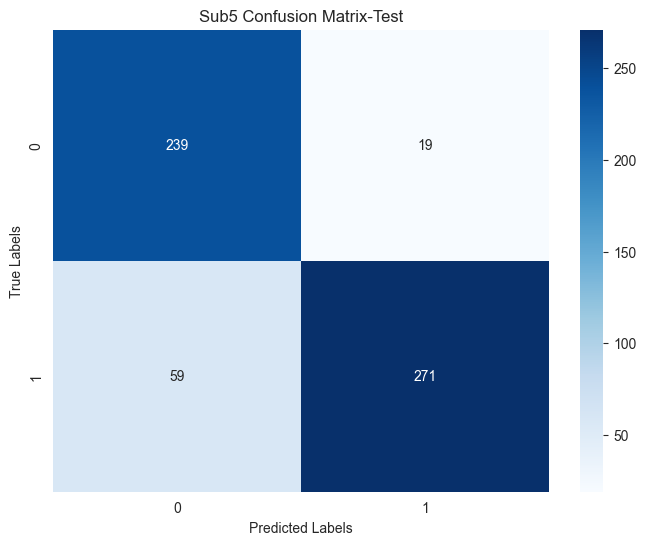

第 4 折（测试序号3）Acc: 86.73%

========== 开始第 5/22 折LOOCV（测试序号：4）==========
Fold [5/22], Epoch [1/500], Step [1/42], Loss: 0.8194
Fold [5/22], Epoch [1/500], Step [11/42], Loss: 0.6553
Fold [5/22], Epoch [1/500], Step [21/42], Loss: 0.6753
Fold [5/22], Epoch [1/500], Step [31/42], Loss: 0.6557
Fold [5/22], Epoch [1/500], Step [41/42], Loss: 0.6577
Fold [5/22], Epoch [101/500], Step [1/42], Loss: 0.4541
Fold [5/22], Epoch [101/500], Step [11/42], Loss: 0.4644
Fold [5/22], Epoch [101/500], Step [21/42], Loss: 0.4839
Fold [5/22], Epoch [101/500], Step [31/42], Loss: 0.5110
Fold [5/22], Epoch [101/500], Step [41/42], Loss: 0.4676
Fold [5/22], Epoch [201/500], Step [1/42], Loss: 0.4649
Fold [5/22], Epoch [201/500], Step [11/42], Loss: 0.4204
Fold [5/22], Epoch [201/500], Step [21/42], Loss: 0.4542
Fold [5/22], Epoch [201/500], Step [31/42], Loss: 0.4381
Fold [5/22], Epoch [201/500], Step [41/42], Loss: 0.4427
Fold [5/22], Epoch [301/500], Step [1/42], Loss: 0.4451
Fold [5/22], Epoch [301/500], St

<Figure size 640x480 with 0 Axes>

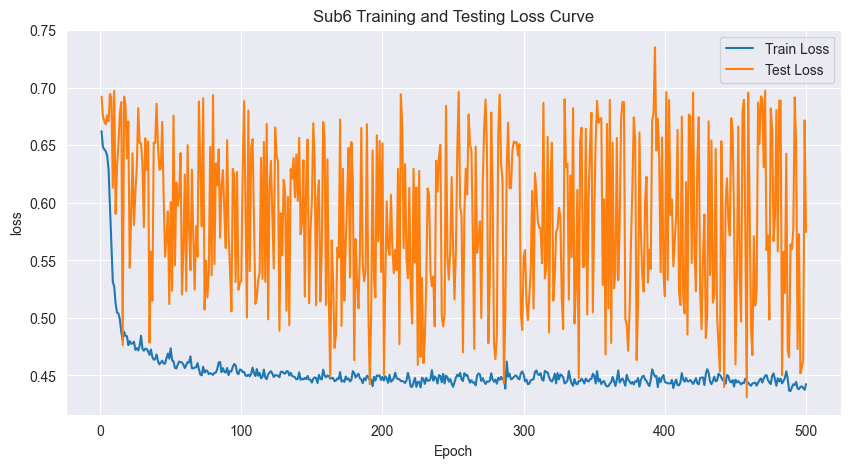

<Figure size 640x480 with 0 Axes>

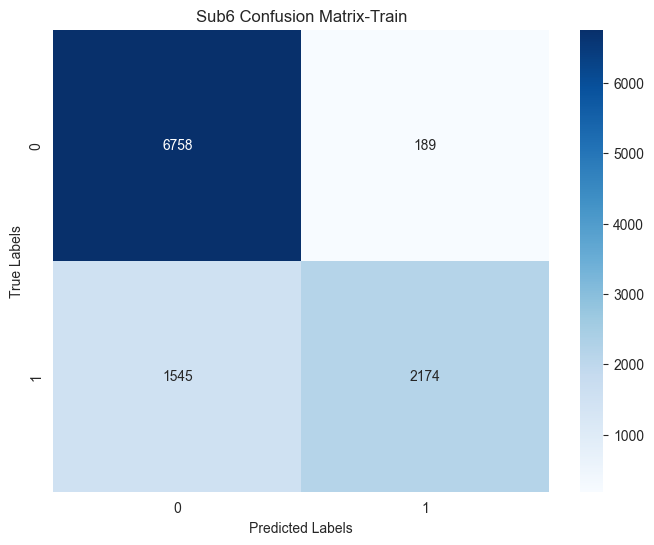

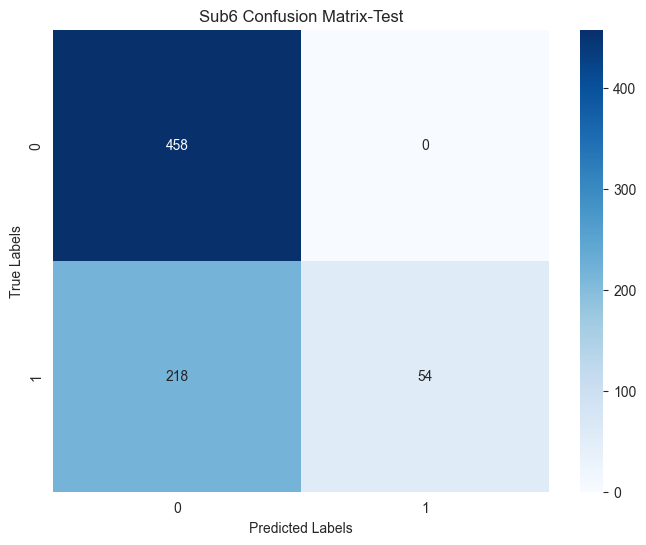

第 5 折（测试序号4）Acc: 70.14%

========== 开始第 6/22 折LOOCV（测试序号：5）==========
Fold [6/22], Epoch [1/500], Step [1/43], Loss: 0.8692
Fold [6/22], Epoch [1/500], Step [11/43], Loss: 0.6491
Fold [6/22], Epoch [1/500], Step [21/43], Loss: 0.6531
Fold [6/22], Epoch [1/500], Step [31/43], Loss: 0.6179
Fold [6/22], Epoch [1/500], Step [41/43], Loss: 0.6726
Fold [6/22], Epoch [101/500], Step [1/43], Loss: 0.4549
Fold [6/22], Epoch [101/500], Step [11/43], Loss: 0.4733
Fold [6/22], Epoch [101/500], Step [21/43], Loss: 0.4090
Fold [6/22], Epoch [101/500], Step [31/43], Loss: 0.4587
Fold [6/22], Epoch [101/500], Step [41/43], Loss: 0.4391
Fold [6/22], Epoch [201/500], Step [1/43], Loss: 0.4527
Fold [6/22], Epoch [201/500], Step [11/43], Loss: 0.4155
Fold [6/22], Epoch [201/500], Step [21/43], Loss: 0.4239
Fold [6/22], Epoch [201/500], Step [31/43], Loss: 0.4539
Fold [6/22], Epoch [201/500], Step [41/43], Loss: 0.4596
Fold [6/22], Epoch [301/500], Step [1/43], Loss: 0.4381
Fold [6/22], Epoch [301/500], St

<Figure size 640x480 with 0 Axes>

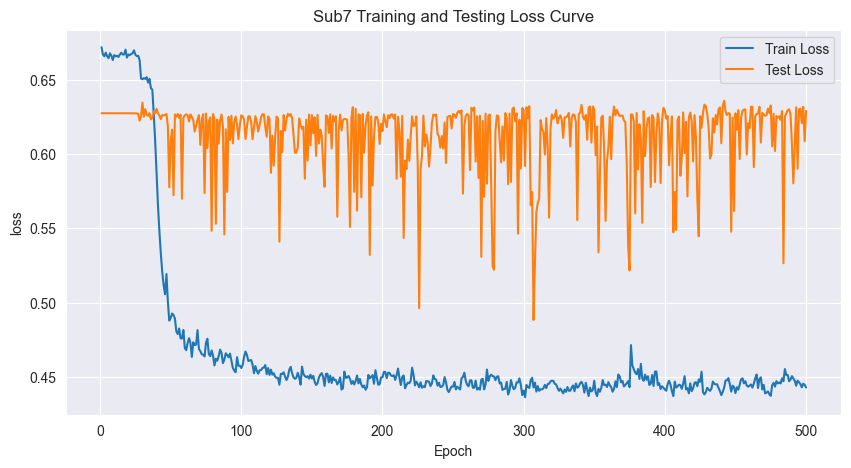

<Figure size 640x480 with 0 Axes>

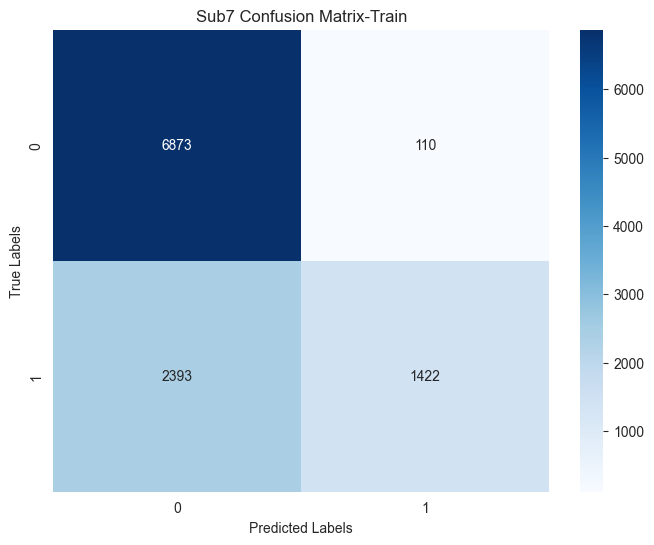

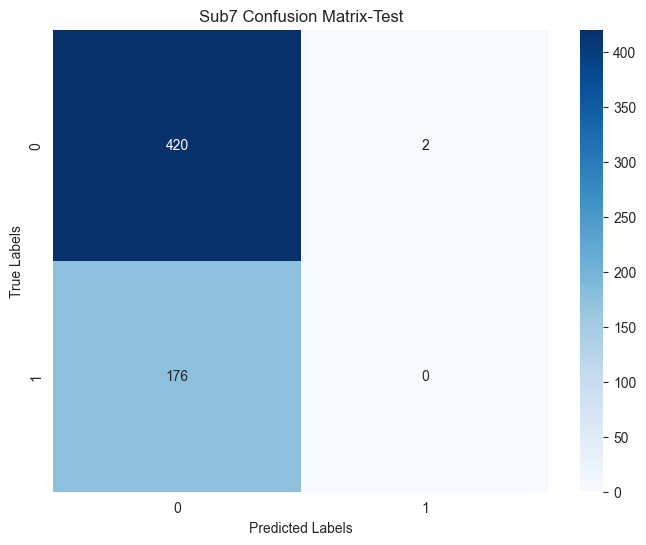

第 6 折（测试序号5）Acc: 70.23%

========== 开始第 7/22 折LOOCV（测试序号：6）==========
Fold [7/22], Epoch [1/500], Step [1/44], Loss: 0.6872
Fold [7/22], Epoch [1/500], Step [11/44], Loss: 0.6770
Fold [7/22], Epoch [1/500], Step [21/44], Loss: 0.6655
Fold [7/22], Epoch [1/500], Step [31/44], Loss: 0.6367
Fold [7/22], Epoch [1/500], Step [41/44], Loss: 0.6608
Fold [7/22], Epoch [101/500], Step [1/44], Loss: 0.4092
Fold [7/22], Epoch [101/500], Step [11/44], Loss: 0.4623
Fold [7/22], Epoch [101/500], Step [21/44], Loss: 0.4304
Fold [7/22], Epoch [101/500], Step [31/44], Loss: 0.4294
Fold [7/22], Epoch [101/500], Step [41/44], Loss: 0.4454
Fold [7/22], Epoch [201/500], Step [1/44], Loss: 0.4348
Fold [7/22], Epoch [201/500], Step [11/44], Loss: 0.4288
Fold [7/22], Epoch [201/500], Step [21/44], Loss: 0.4461
Fold [7/22], Epoch [201/500], Step [31/44], Loss: 0.4052
Fold [7/22], Epoch [201/500], Step [41/44], Loss: 0.4445
Fold [7/22], Epoch [301/500], Step [1/44], Loss: 0.4538
Fold [7/22], Epoch [301/500], St

<Figure size 640x480 with 0 Axes>

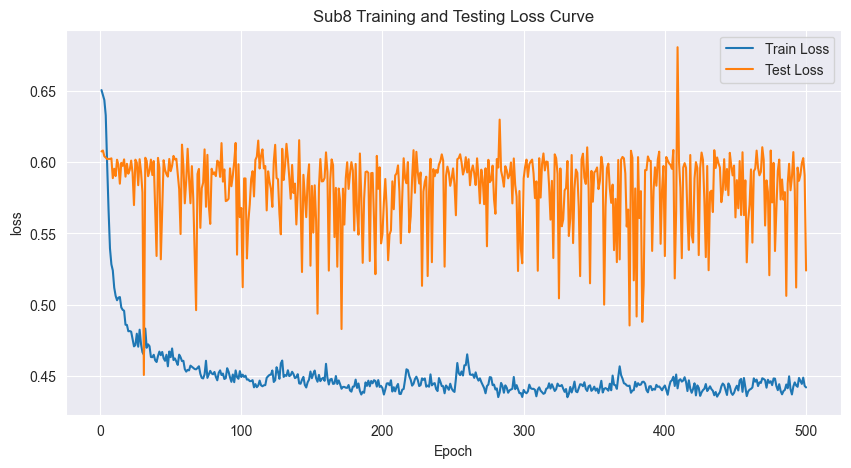

<Figure size 640x480 with 0 Axes>

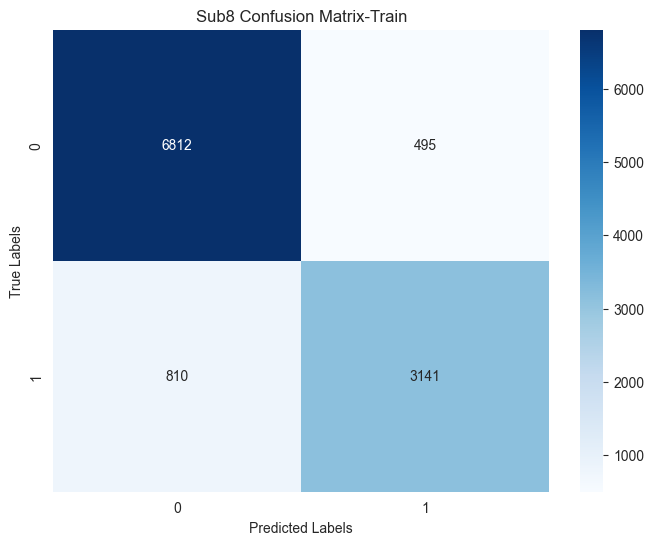

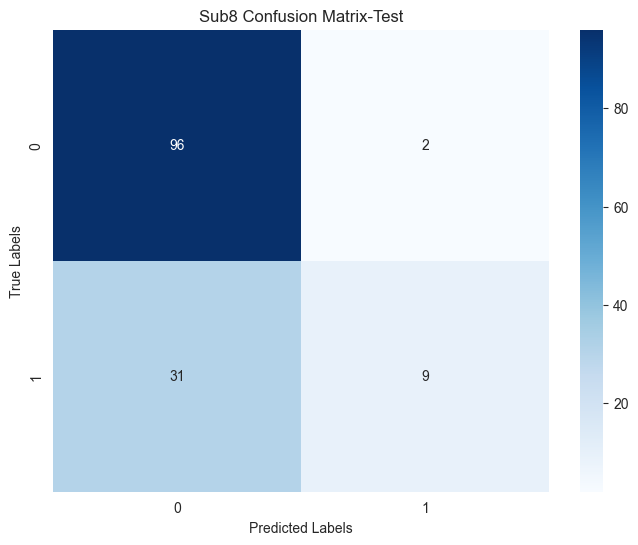

第 7 折（测试序号6）Acc: 76.09%

========== 开始第 8/22 折LOOCV（测试序号：7）==========
Fold [8/22], Epoch [1/500], Step [1/44], Loss: 0.7067
Fold [8/22], Epoch [1/500], Step [11/44], Loss: 0.6732
Fold [8/22], Epoch [1/500], Step [21/44], Loss: 0.6891
Fold [8/22], Epoch [1/500], Step [31/44], Loss: 0.6499
Fold [8/22], Epoch [1/500], Step [41/44], Loss: 0.6282
Fold [8/22], Epoch [101/500], Step [1/44], Loss: 0.4388
Fold [8/22], Epoch [101/500], Step [11/44], Loss: 0.4251
Fold [8/22], Epoch [101/500], Step [21/44], Loss: 0.5095
Fold [8/22], Epoch [101/500], Step [31/44], Loss: 0.4625
Fold [8/22], Epoch [101/500], Step [41/44], Loss: 0.4509
Fold [8/22], Epoch [201/500], Step [1/44], Loss: 0.4196
Fold [8/22], Epoch [201/500], Step [11/44], Loss: 0.4192
Fold [8/22], Epoch [201/500], Step [21/44], Loss: 0.4407
Fold [8/22], Epoch [201/500], Step [31/44], Loss: 0.4081
Fold [8/22], Epoch [201/500], Step [41/44], Loss: 0.4404
Fold [8/22], Epoch [301/500], Step [1/44], Loss: 0.4572
Fold [8/22], Epoch [301/500], St

<Figure size 640x480 with 0 Axes>

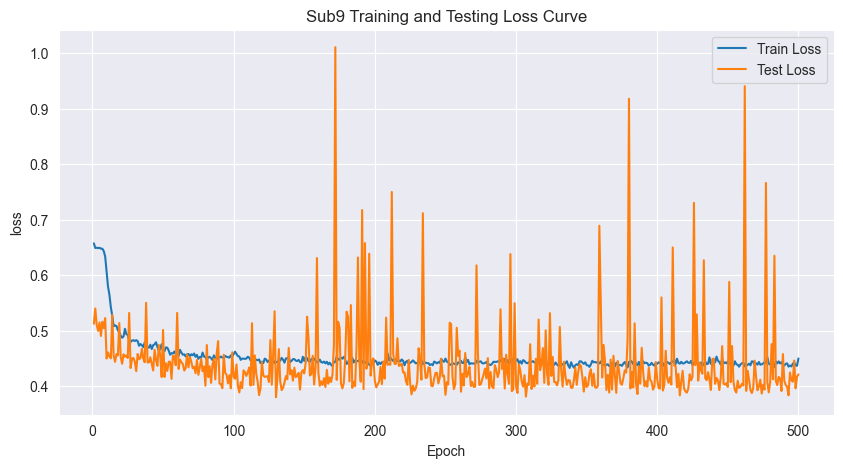

<Figure size 640x480 with 0 Axes>

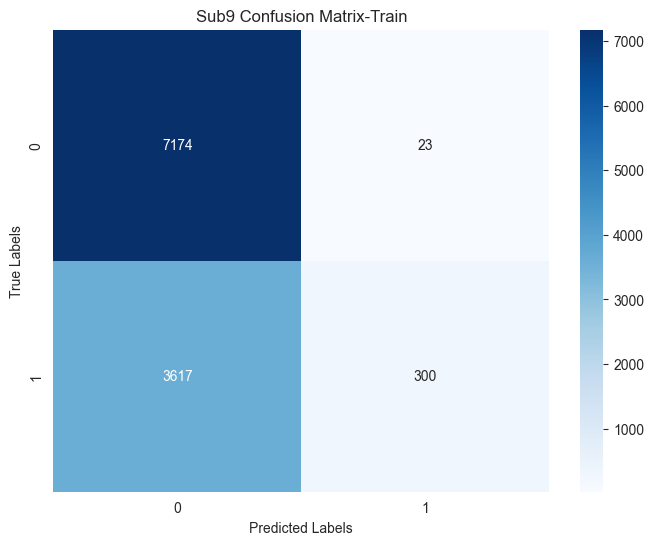

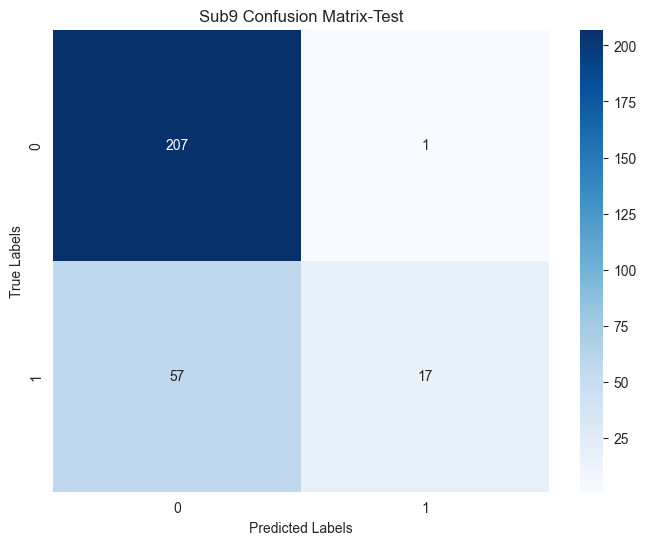

第 8 折（测试序号7）Acc: 79.43%

========== 开始第 9/22 折LOOCV（测试序号：8）==========
Fold [9/22], Epoch [1/500], Step [1/44], Loss: 0.7091
Fold [9/22], Epoch [1/500], Step [11/44], Loss: 0.7121
Fold [9/22], Epoch [1/500], Step [21/44], Loss: 0.7050
Fold [9/22], Epoch [1/500], Step [31/44], Loss: 0.6466
Fold [9/22], Epoch [1/500], Step [41/44], Loss: 0.6507
Fold [9/22], Epoch [101/500], Step [1/44], Loss: 0.4513
Fold [9/22], Epoch [101/500], Step [11/44], Loss: 0.4435
Fold [9/22], Epoch [101/500], Step [21/44], Loss: 0.4279
Fold [9/22], Epoch [101/500], Step [31/44], Loss: 0.4515
Fold [9/22], Epoch [101/500], Step [41/44], Loss: 0.4215
Fold [9/22], Epoch [201/500], Step [1/44], Loss: 0.4706
Fold [9/22], Epoch [201/500], Step [11/44], Loss: 0.4731
Fold [9/22], Epoch [201/500], Step [21/44], Loss: 0.4161
Fold [9/22], Epoch [201/500], Step [31/44], Loss: 0.4275
Fold [9/22], Epoch [201/500], Step [41/44], Loss: 0.4270
Fold [9/22], Epoch [301/500], Step [1/44], Loss: 0.4555
Fold [9/22], Epoch [301/500], St

<Figure size 640x480 with 0 Axes>

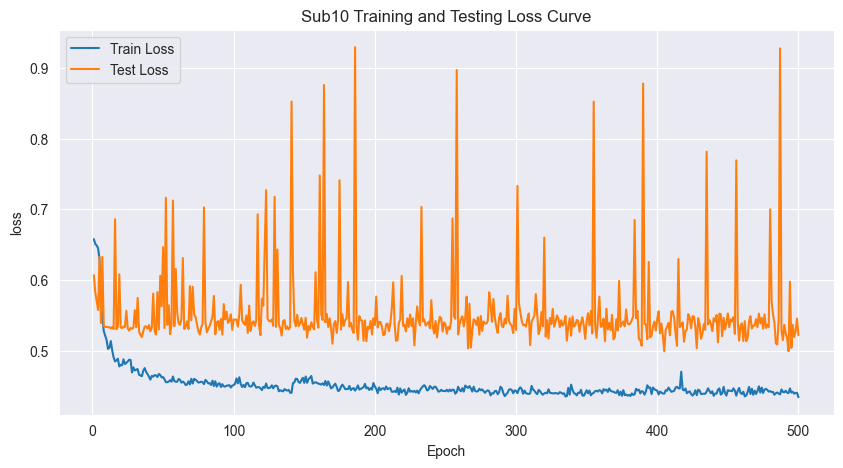

<Figure size 640x480 with 0 Axes>

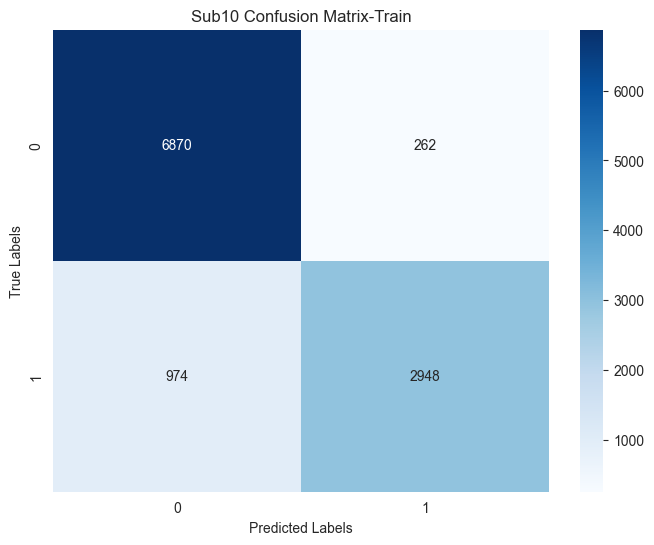

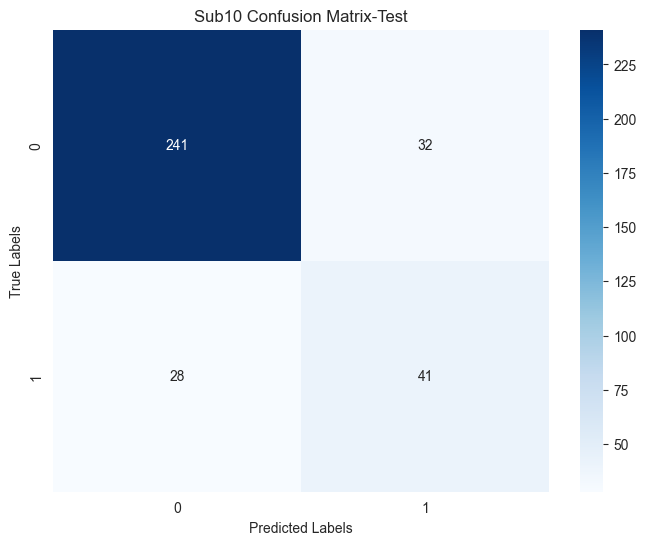

第 9 折（测试序号8）Acc: 82.46%

========== 开始第 10/22 折LOOCV（测试序号：9）==========
Fold [10/22], Epoch [1/500], Step [1/42], Loss: 0.7145
Fold [10/22], Epoch [1/500], Step [11/42], Loss: 0.6121
Fold [10/22], Epoch [1/500], Step [21/42], Loss: 0.6448
Fold [10/22], Epoch [1/500], Step [31/42], Loss: 0.6281
Fold [10/22], Epoch [1/500], Step [41/42], Loss: 0.6744
Fold [10/22], Epoch [101/500], Step [1/42], Loss: 0.4449
Fold [10/22], Epoch [101/500], Step [11/42], Loss: 0.4237
Fold [10/22], Epoch [101/500], Step [21/42], Loss: 0.4477
Fold [10/22], Epoch [101/500], Step [31/42], Loss: 0.4242
Fold [10/22], Epoch [101/500], Step [41/42], Loss: 0.4388
Fold [10/22], Epoch [201/500], Step [1/42], Loss: 0.4886
Fold [10/22], Epoch [201/500], Step [11/42], Loss: 0.4709
Fold [10/22], Epoch [201/500], Step [21/42], Loss: 0.4340
Fold [10/22], Epoch [201/500], Step [31/42], Loss: 0.4423
Fold [10/22], Epoch [201/500], Step [41/42], Loss: 0.4032
Fold [10/22], Epoch [301/500], Step [1/42], Loss: 0.4309
Fold [10/22], E

<Figure size 640x480 with 0 Axes>

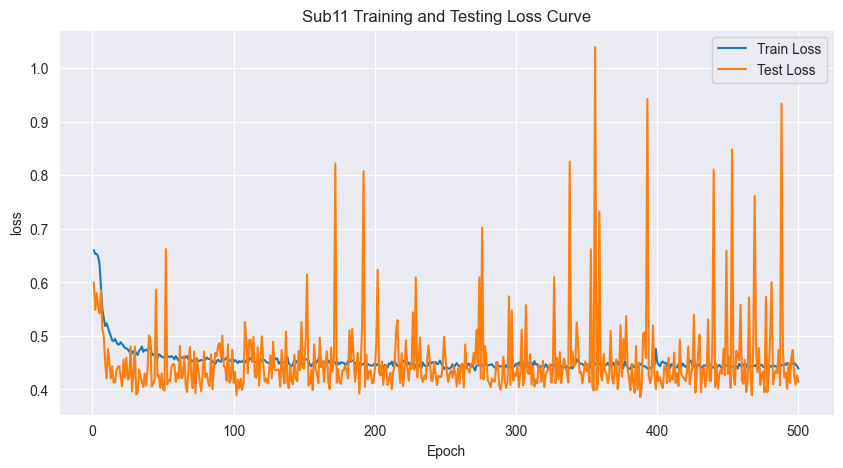

<Figure size 640x480 with 0 Axes>

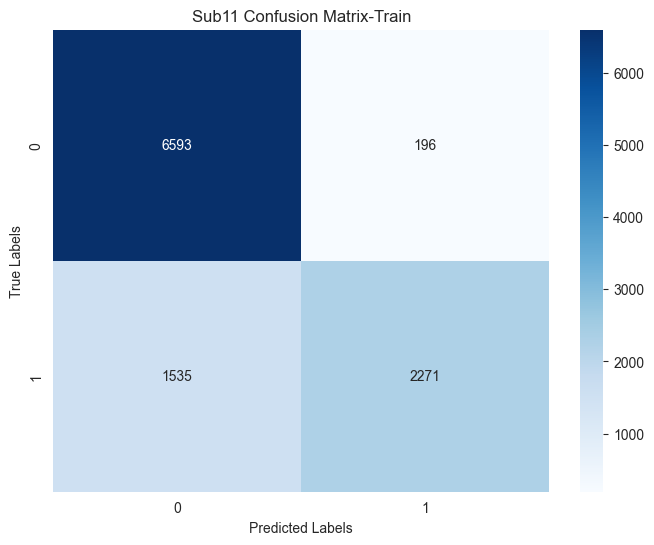

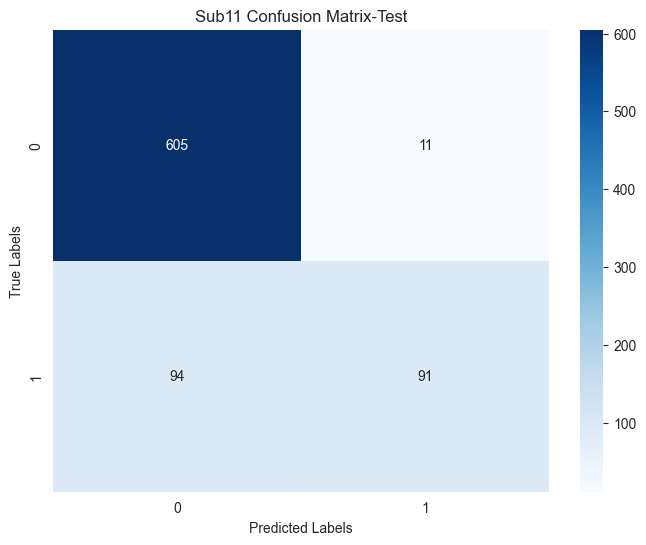

第 10 折（测试序号9）Acc: 86.89%

========== 开始第 11/22 折LOOCV（测试序号：10）==========
Fold [11/22], Epoch [1/500], Step [1/42], Loss: 0.7106
Fold [11/22], Epoch [1/500], Step [11/42], Loss: 0.6397
Fold [11/22], Epoch [1/500], Step [21/42], Loss: 0.6518
Fold [11/22], Epoch [1/500], Step [31/42], Loss: 0.6931
Fold [11/22], Epoch [1/500], Step [41/42], Loss: 0.6524
Fold [11/22], Epoch [101/500], Step [1/42], Loss: 0.4545
Fold [11/22], Epoch [101/500], Step [11/42], Loss: 0.4532
Fold [11/22], Epoch [101/500], Step [21/42], Loss: 0.4564
Fold [11/22], Epoch [101/500], Step [31/42], Loss: 0.4767
Fold [11/22], Epoch [101/500], Step [41/42], Loss: 0.4509
Fold [11/22], Epoch [201/500], Step [1/42], Loss: 0.4596
Fold [11/22], Epoch [201/500], Step [11/42], Loss: 0.4343
Fold [11/22], Epoch [201/500], Step [21/42], Loss: 0.5373
Fold [11/22], Epoch [201/500], Step [31/42], Loss: 0.4717
Fold [11/22], Epoch [201/500], Step [41/42], Loss: 0.4638
Fold [11/22], Epoch [301/500], Step [1/42], Loss: 0.4744
Fold [11/22],

<Figure size 640x480 with 0 Axes>

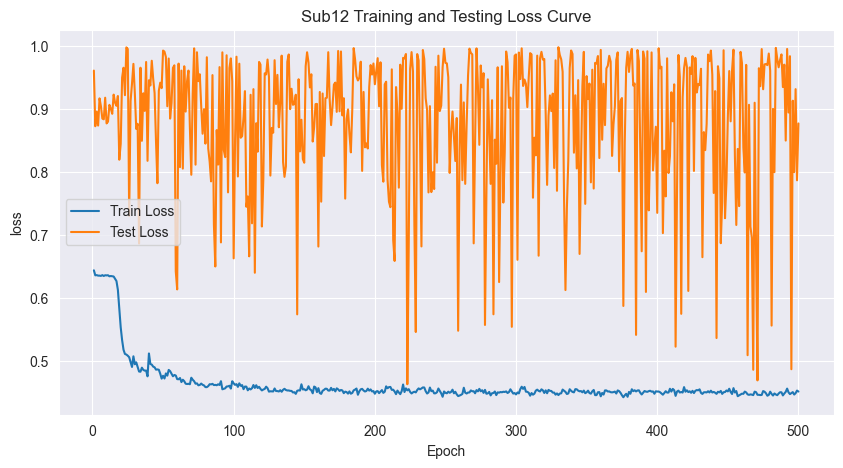

<Figure size 640x480 with 0 Axes>

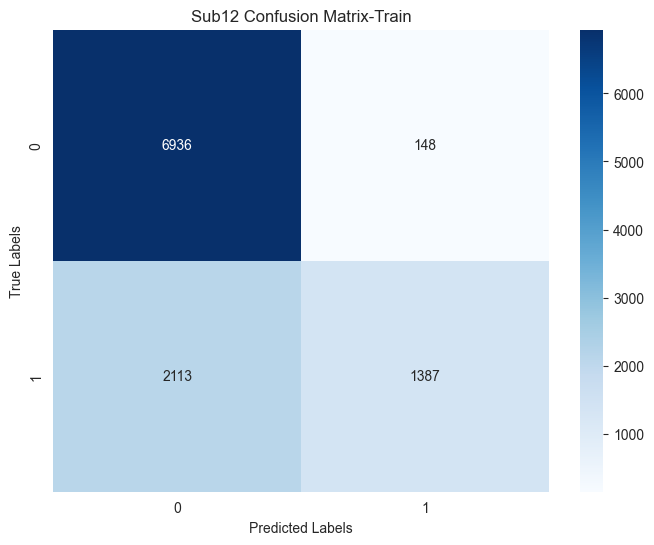

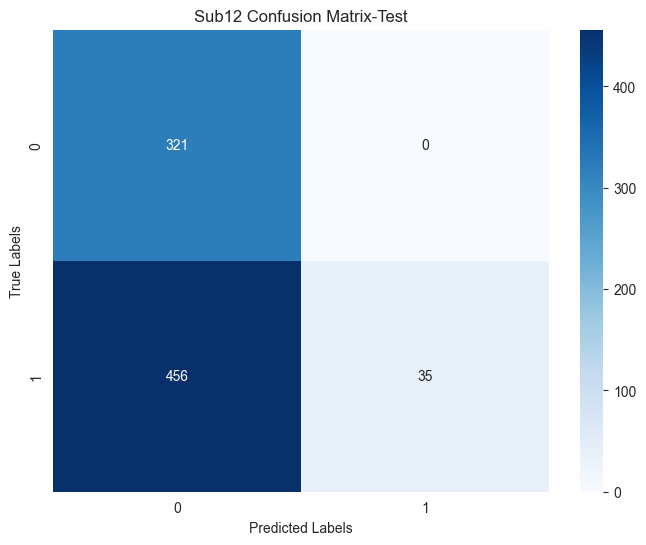

第 11 折（测试序号10）Acc: 43.84%

========== 开始第 12/22 折LOOCV（测试序号：11）==========
Fold [12/22], Epoch [1/500], Step [1/43], Loss: 0.6842
Fold [12/22], Epoch [1/500], Step [11/43], Loss: 0.6233
Fold [12/22], Epoch [1/500], Step [21/43], Loss: 0.5909
Fold [12/22], Epoch [1/500], Step [31/43], Loss: 0.6548
Fold [12/22], Epoch [1/500], Step [41/43], Loss: 0.6693
Fold [12/22], Epoch [101/500], Step [1/43], Loss: 0.4675
Fold [12/22], Epoch [101/500], Step [11/43], Loss: 0.4492
Fold [12/22], Epoch [101/500], Step [21/43], Loss: 0.4423
Fold [12/22], Epoch [101/500], Step [31/43], Loss: 0.4219
Fold [12/22], Epoch [101/500], Step [41/43], Loss: 0.4590
Fold [12/22], Epoch [201/500], Step [1/43], Loss: 0.4339
Fold [12/22], Epoch [201/500], Step [11/43], Loss: 0.4805
Fold [12/22], Epoch [201/500], Step [21/43], Loss: 0.4295
Fold [12/22], Epoch [201/500], Step [31/43], Loss: 0.4422
Fold [12/22], Epoch [201/500], Step [41/43], Loss: 0.4590
Fold [12/22], Epoch [301/500], Step [1/43], Loss: 0.4275
Fold [12/22]

<Figure size 640x480 with 0 Axes>

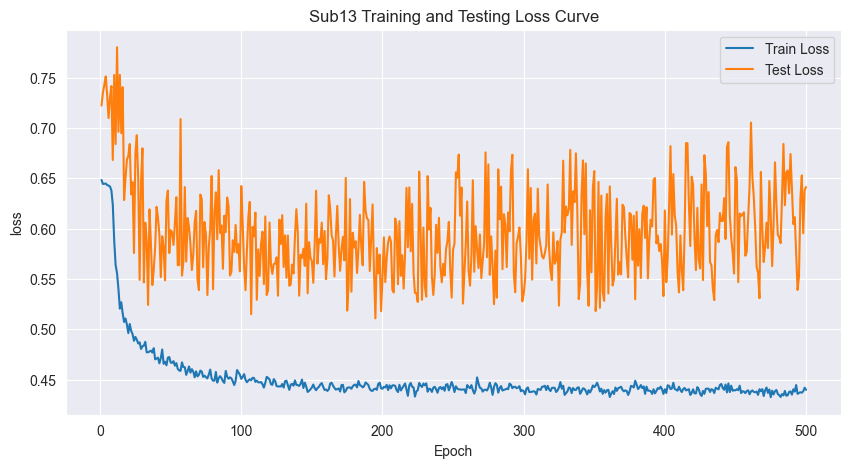

<Figure size 640x480 with 0 Axes>

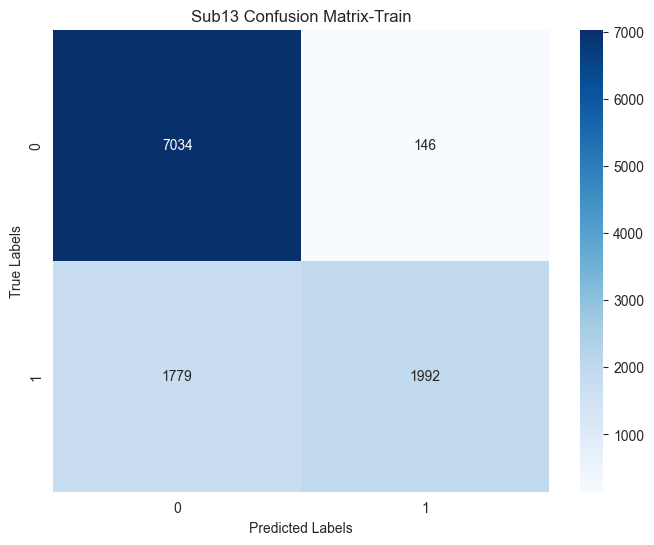

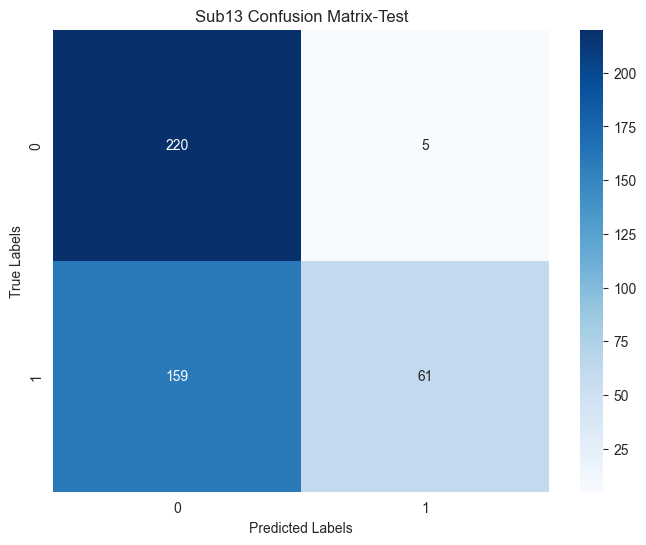

第 12 折（测试序号11）Acc: 63.15%

========== 开始第 13/22 折LOOCV（测试序号：12）==========
Fold [13/22], Epoch [1/500], Step [1/44], Loss: 0.6552
Fold [13/22], Epoch [1/500], Step [11/44], Loss: 0.6536
Fold [13/22], Epoch [1/500], Step [21/44], Loss: 0.6986
Fold [13/22], Epoch [1/500], Step [31/44], Loss: 0.6815
Fold [13/22], Epoch [1/500], Step [41/44], Loss: 0.6368
Fold [13/22], Epoch [101/500], Step [1/44], Loss: 0.4455
Fold [13/22], Epoch [101/500], Step [11/44], Loss: 0.4620
Fold [13/22], Epoch [101/500], Step [21/44], Loss: 0.4644
Fold [13/22], Epoch [101/500], Step [31/44], Loss: 0.4743
Fold [13/22], Epoch [101/500], Step [41/44], Loss: 0.4471
Fold [13/22], Epoch [201/500], Step [1/44], Loss: 0.4100
Fold [13/22], Epoch [201/500], Step [11/44], Loss: 0.4583
Fold [13/22], Epoch [201/500], Step [21/44], Loss: 0.4404
Fold [13/22], Epoch [201/500], Step [31/44], Loss: 0.4528
Fold [13/22], Epoch [201/500], Step [41/44], Loss: 0.4490
Fold [13/22], Epoch [301/500], Step [1/44], Loss: 0.4476
Fold [13/22]

<Figure size 640x480 with 0 Axes>

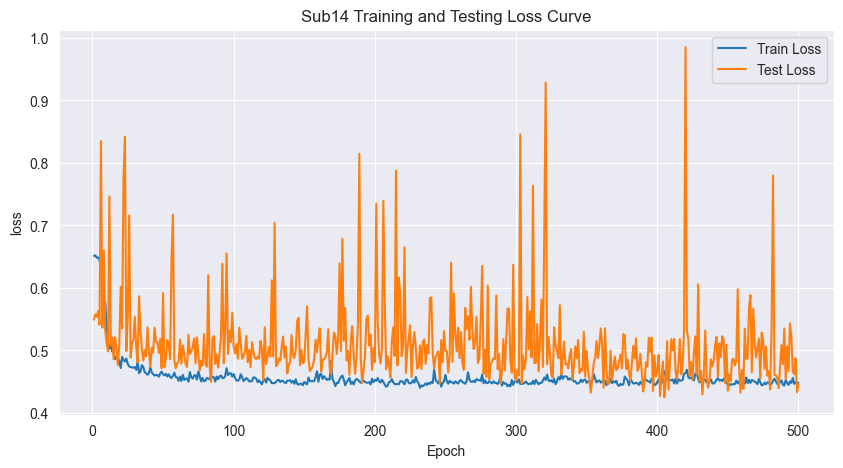

<Figure size 640x480 with 0 Axes>

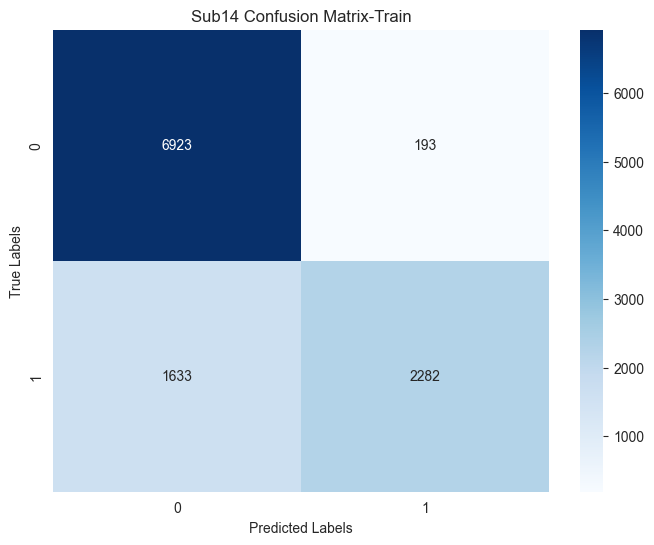

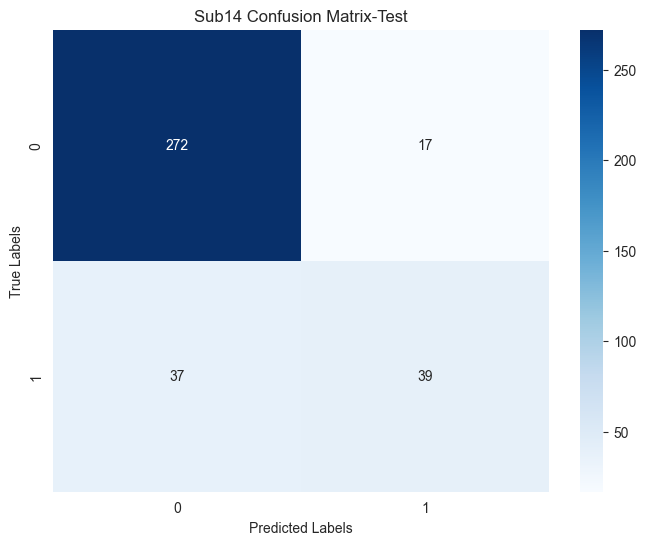

第 13 折（测试序号12）Acc: 85.21%

========== 开始第 14/22 折LOOCV（测试序号：13）==========
Fold [14/22], Epoch [1/500], Step [1/42], Loss: 0.7406
Fold [14/22], Epoch [1/500], Step [11/42], Loss: 0.5983
Fold [14/22], Epoch [1/500], Step [21/42], Loss: 0.6334
Fold [14/22], Epoch [1/500], Step [31/42], Loss: 0.6335
Fold [14/22], Epoch [1/500], Step [41/42], Loss: 0.6647
Fold [14/22], Epoch [101/500], Step [1/42], Loss: 0.4410
Fold [14/22], Epoch [101/500], Step [11/42], Loss: 0.4520
Fold [14/22], Epoch [101/500], Step [21/42], Loss: 0.4380
Fold [14/22], Epoch [101/500], Step [31/42], Loss: 0.4555
Fold [14/22], Epoch [101/500], Step [41/42], Loss: 0.4346
Fold [14/22], Epoch [201/500], Step [1/42], Loss: 0.4551
Fold [14/22], Epoch [201/500], Step [11/42], Loss: 0.4849
Fold [14/22], Epoch [201/500], Step [21/42], Loss: 0.4481
Fold [14/22], Epoch [201/500], Step [31/42], Loss: 0.4336
Fold [14/22], Epoch [201/500], Step [41/42], Loss: 0.4461
Fold [14/22], Epoch [301/500], Step [1/42], Loss: 0.4386
Fold [14/22]

<Figure size 640x480 with 0 Axes>

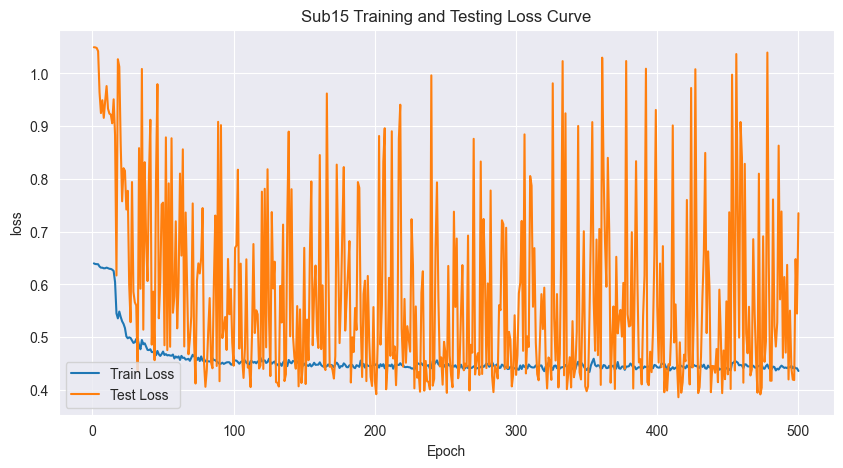

<Figure size 640x480 with 0 Axes>

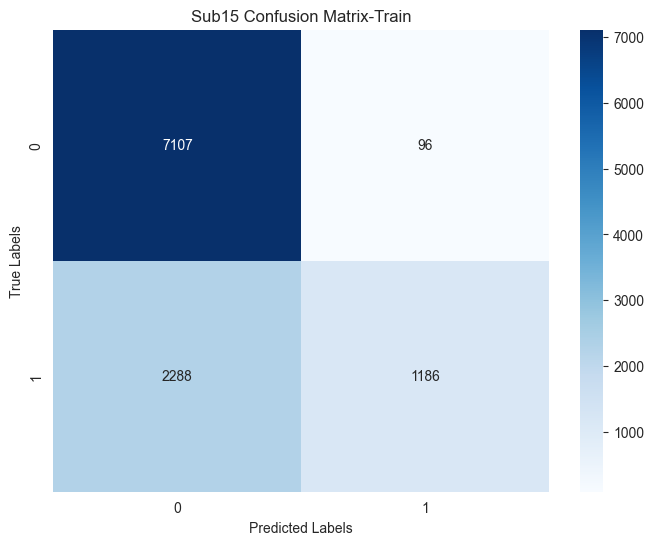

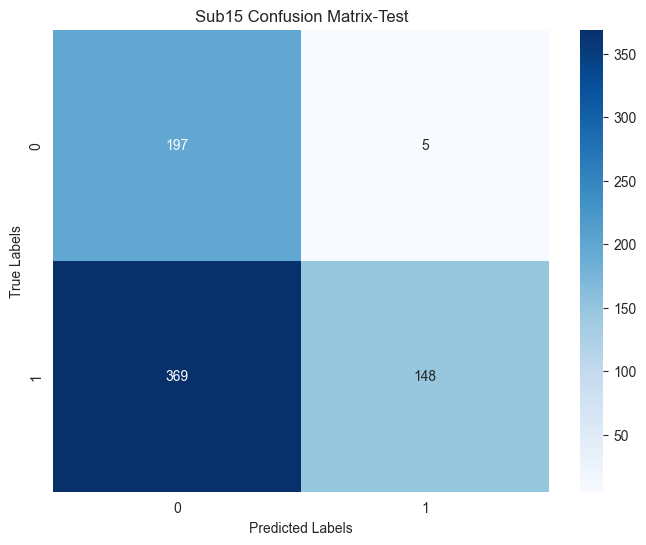

第 14 折（测试序号13）Acc: 47.98%

========== 开始第 15/22 折LOOCV（测试序号：14）==========
Fold [15/22], Epoch [1/500], Step [1/42], Loss: 0.6767
Fold [15/22], Epoch [1/500], Step [11/42], Loss: 0.6759
Fold [15/22], Epoch [1/500], Step [21/42], Loss: 0.6779
Fold [15/22], Epoch [1/500], Step [31/42], Loss: 0.6675
Fold [15/22], Epoch [1/500], Step [41/42], Loss: 0.6462
Fold [15/22], Epoch [101/500], Step [1/42], Loss: 0.4530
Fold [15/22], Epoch [101/500], Step [11/42], Loss: 0.4507
Fold [15/22], Epoch [101/500], Step [21/42], Loss: 0.4532
Fold [15/22], Epoch [101/500], Step [31/42], Loss: 0.4528
Fold [15/22], Epoch [101/500], Step [41/42], Loss: 0.4874
Fold [15/22], Epoch [201/500], Step [1/42], Loss: 0.4194
Fold [15/22], Epoch [201/500], Step [11/42], Loss: 0.4092
Fold [15/22], Epoch [201/500], Step [21/42], Loss: 0.4222
Fold [15/22], Epoch [201/500], Step [31/42], Loss: 0.4175
Fold [15/22], Epoch [201/500], Step [41/42], Loss: 0.4504
Fold [15/22], Epoch [301/500], Step [1/42], Loss: 0.4582
Fold [15/22]

<Figure size 640x480 with 0 Axes>

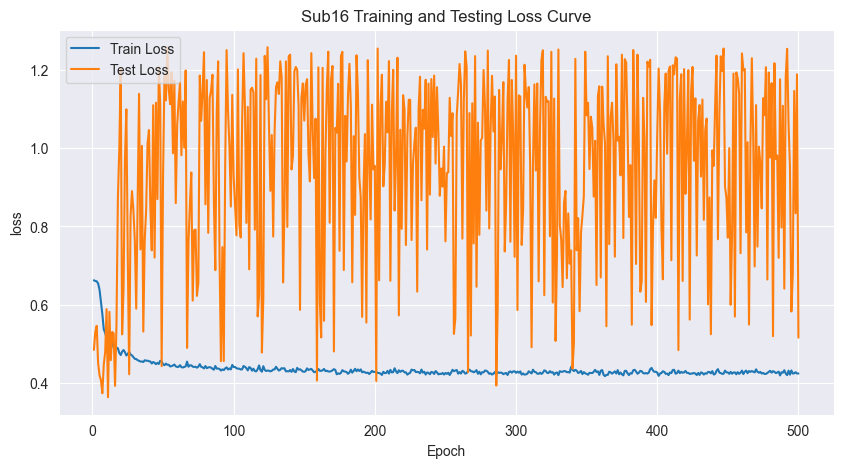

<Figure size 640x480 with 0 Axes>

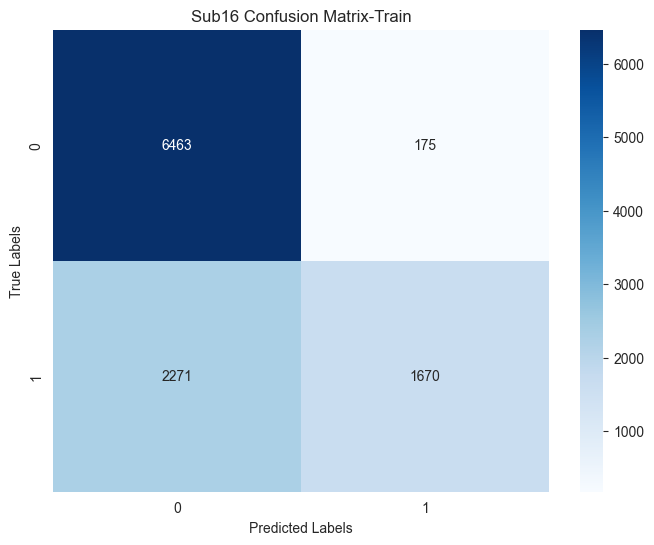

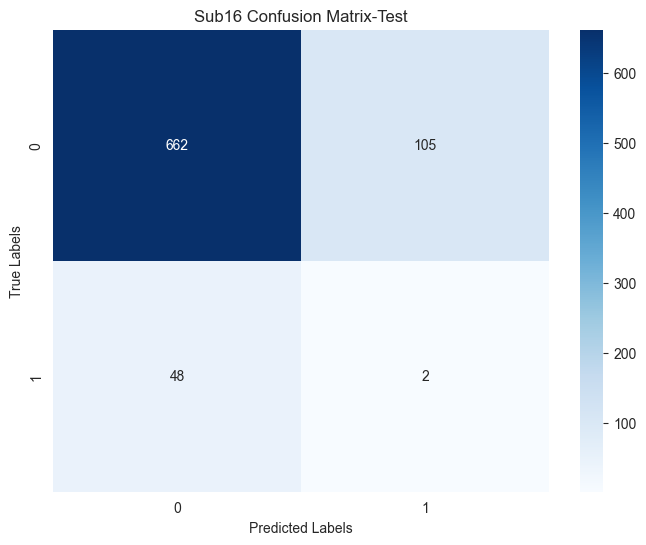

第 15 折（测试序号14）Acc: 81.27%

========== 开始第 16/22 折LOOCV（测试序号：15）==========
Fold [16/22], Epoch [1/500], Step [1/42], Loss: 0.6695
Fold [16/22], Epoch [1/500], Step [11/42], Loss: 0.6513
Fold [16/22], Epoch [1/500], Step [21/42], Loss: 0.6666
Fold [16/22], Epoch [1/500], Step [31/42], Loss: 0.6409
Fold [16/22], Epoch [1/500], Step [41/42], Loss: 0.6449
Fold [16/22], Epoch [101/500], Step [1/42], Loss: 0.4809
Fold [16/22], Epoch [101/500], Step [11/42], Loss: 0.4199
Fold [16/22], Epoch [101/500], Step [21/42], Loss: 0.4236
Fold [16/22], Epoch [101/500], Step [31/42], Loss: 0.4589
Fold [16/22], Epoch [101/500], Step [41/42], Loss: 0.4446
Fold [16/22], Epoch [201/500], Step [1/42], Loss: 0.4364
Fold [16/22], Epoch [201/500], Step [11/42], Loss: 0.4684
Fold [16/22], Epoch [201/500], Step [21/42], Loss: 0.4805
Fold [16/22], Epoch [201/500], Step [31/42], Loss: 0.4464
Fold [16/22], Epoch [201/500], Step [41/42], Loss: 0.4422
Fold [16/22], Epoch [301/500], Step [1/42], Loss: 0.4117
Fold [16/22]

<Figure size 640x480 with 0 Axes>

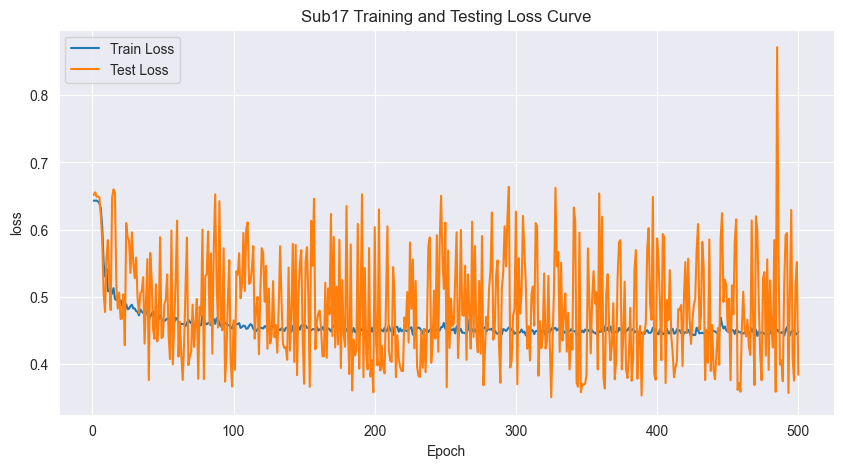

<Figure size 640x480 with 0 Axes>

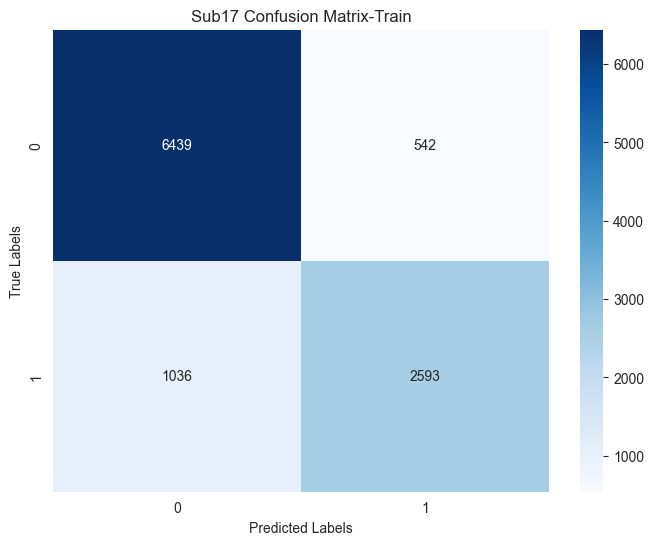

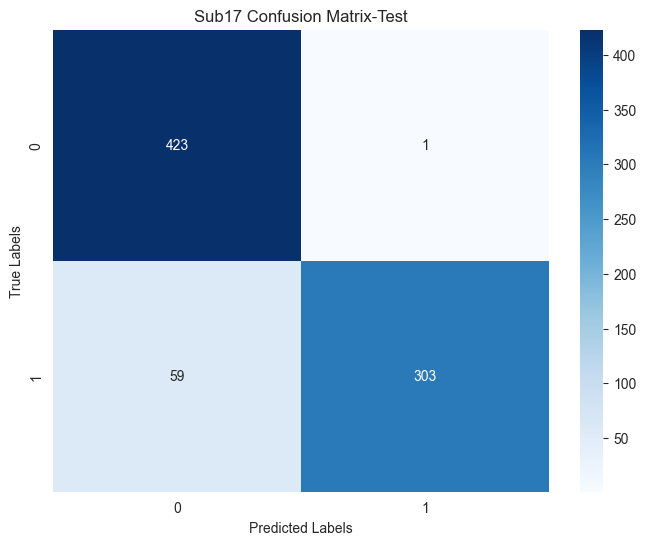

第 16 折（测试序号15）Acc: 92.37%

========== 开始第 17/22 折LOOCV（测试序号：16）==========
Fold [17/22], Epoch [1/500], Step [1/44], Loss: 0.6692
Fold [17/22], Epoch [1/500], Step [11/44], Loss: 0.6579
Fold [17/22], Epoch [1/500], Step [21/44], Loss: 0.6427
Fold [17/22], Epoch [1/500], Step [31/44], Loss: 0.6391
Fold [17/22], Epoch [1/500], Step [41/44], Loss: 0.6714
Fold [17/22], Epoch [101/500], Step [1/44], Loss: 0.4321
Fold [17/22], Epoch [101/500], Step [11/44], Loss: 0.4679
Fold [17/22], Epoch [101/500], Step [21/44], Loss: 0.4908
Fold [17/22], Epoch [101/500], Step [31/44], Loss: 0.4367
Fold [17/22], Epoch [101/500], Step [41/44], Loss: 0.4500
Fold [17/22], Epoch [201/500], Step [1/44], Loss: 0.3992
Fold [17/22], Epoch [201/500], Step [11/44], Loss: 0.4277
Fold [17/22], Epoch [201/500], Step [21/44], Loss: 0.4832
Fold [17/22], Epoch [201/500], Step [31/44], Loss: 0.5273
Fold [17/22], Epoch [201/500], Step [41/44], Loss: 0.4200
Fold [17/22], Epoch [301/500], Step [1/44], Loss: 0.4165
Fold [17/22]

<Figure size 640x480 with 0 Axes>

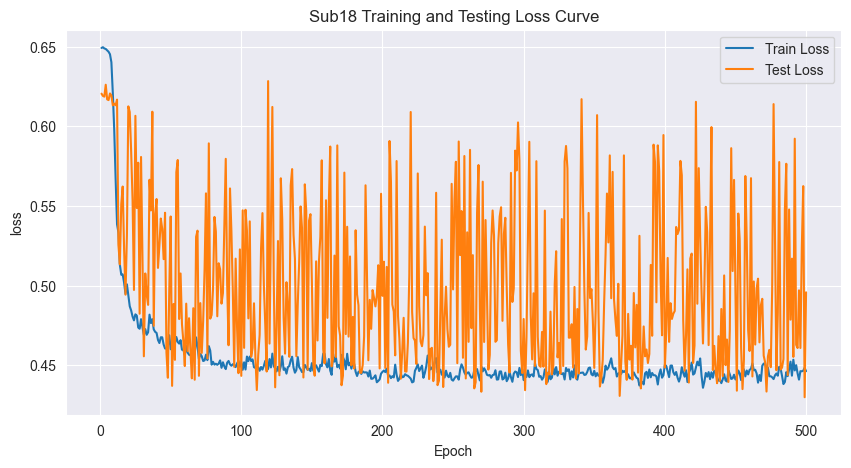

<Figure size 640x480 with 0 Axes>

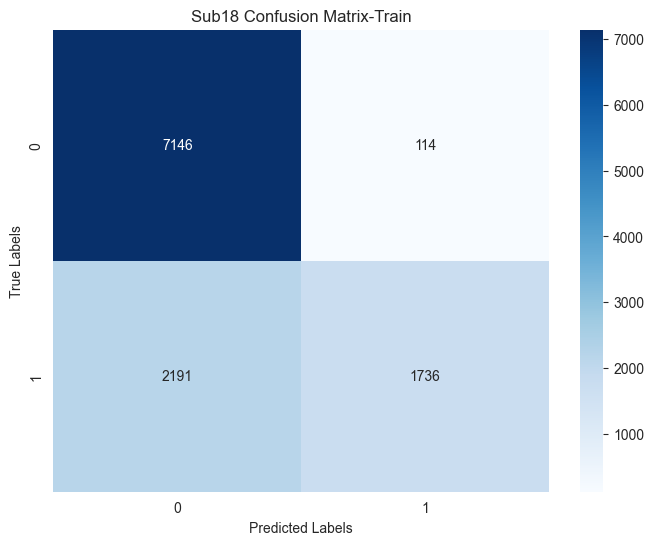

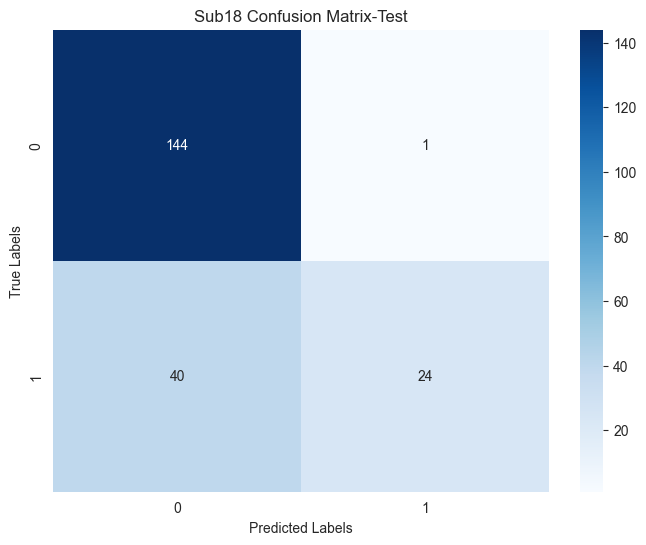

第 17 折（测试序号16）Acc: 80.38%

========== 开始第 18/22 折LOOCV（测试序号：17）==========
Fold [18/22], Epoch [1/500], Step [1/42], Loss: 0.6609
Fold [18/22], Epoch [1/500], Step [11/42], Loss: 0.6869
Fold [18/22], Epoch [1/500], Step [21/42], Loss: 0.6551
Fold [18/22], Epoch [1/500], Step [31/42], Loss: 0.6627
Fold [18/22], Epoch [1/500], Step [41/42], Loss: 0.6183
Fold [18/22], Epoch [101/500], Step [1/42], Loss: 0.4241
Fold [18/22], Epoch [101/500], Step [11/42], Loss: 0.4436
Fold [18/22], Epoch [101/500], Step [21/42], Loss: 0.4600
Fold [18/22], Epoch [101/500], Step [31/42], Loss: 0.4437
Fold [18/22], Epoch [101/500], Step [41/42], Loss: 0.4170
Fold [18/22], Epoch [201/500], Step [1/42], Loss: 0.4485
Fold [18/22], Epoch [201/500], Step [11/42], Loss: 0.4725
Fold [18/22], Epoch [201/500], Step [21/42], Loss: 0.4219
Fold [18/22], Epoch [201/500], Step [31/42], Loss: 0.4246
Fold [18/22], Epoch [201/500], Step [41/42], Loss: 0.4169
Fold [18/22], Epoch [301/500], Step [1/42], Loss: 0.4236
Fold [18/22]

<Figure size 640x480 with 0 Axes>

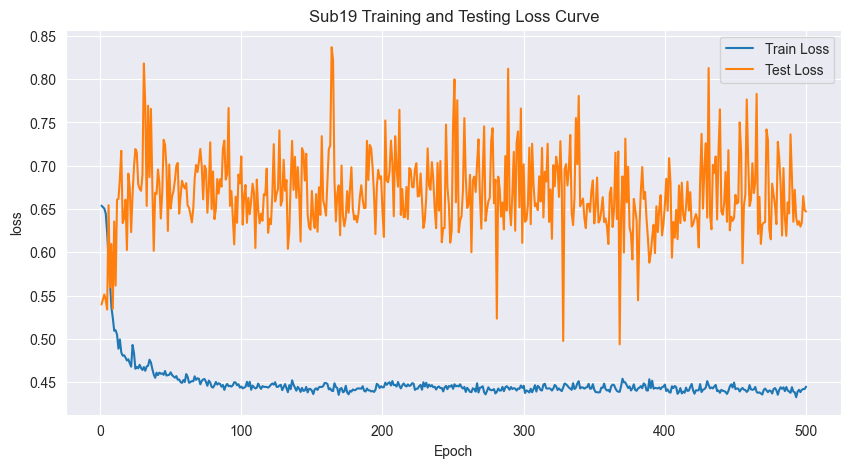

<Figure size 640x480 with 0 Axes>

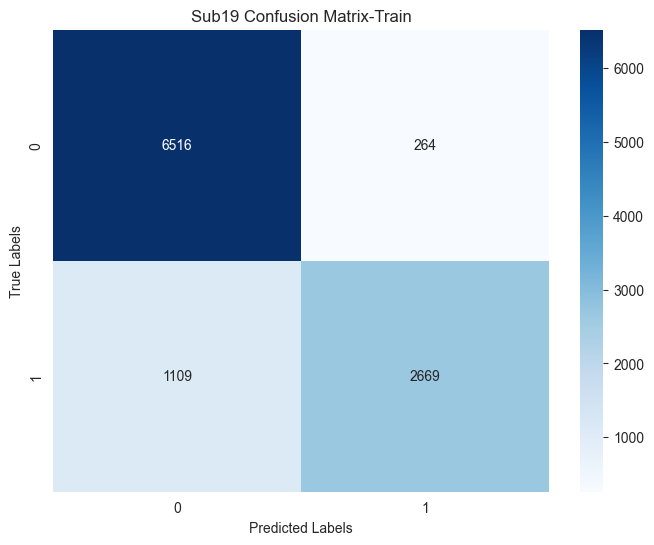

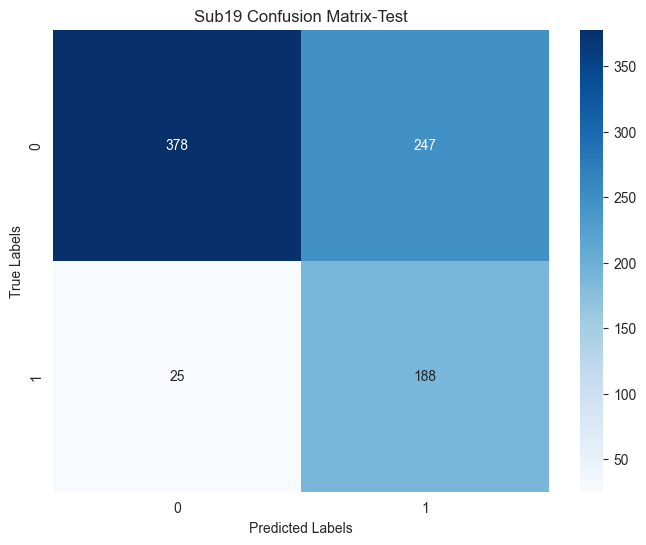

第 18 折（测试序号17）Acc: 67.54%

========== 开始第 19/22 折LOOCV（测试序号：18）==========
Fold [19/22], Epoch [1/500], Step [1/44], Loss: 0.8020
Fold [19/22], Epoch [1/500], Step [11/44], Loss: 0.6953
Fold [19/22], Epoch [1/500], Step [21/44], Loss: 0.6452
Fold [19/22], Epoch [1/500], Step [31/44], Loss: 0.6491
Fold [19/22], Epoch [1/500], Step [41/44], Loss: 0.6570
Fold [19/22], Epoch [101/500], Step [1/44], Loss: 0.4329
Fold [19/22], Epoch [101/500], Step [11/44], Loss: 0.4979
Fold [19/22], Epoch [101/500], Step [21/44], Loss: 0.4401
Fold [19/22], Epoch [101/500], Step [31/44], Loss: 0.4355
Fold [19/22], Epoch [101/500], Step [41/44], Loss: 0.4288
Fold [19/22], Epoch [201/500], Step [1/44], Loss: 0.4281
Fold [19/22], Epoch [201/500], Step [11/44], Loss: 0.5077
Fold [19/22], Epoch [201/500], Step [21/44], Loss: 0.4483
Fold [19/22], Epoch [201/500], Step [31/44], Loss: 0.4413
Fold [19/22], Epoch [201/500], Step [41/44], Loss: 0.4447
Fold [19/22], Epoch [301/500], Step [1/44], Loss: 0.4044
Fold [19/22]

<Figure size 640x480 with 0 Axes>

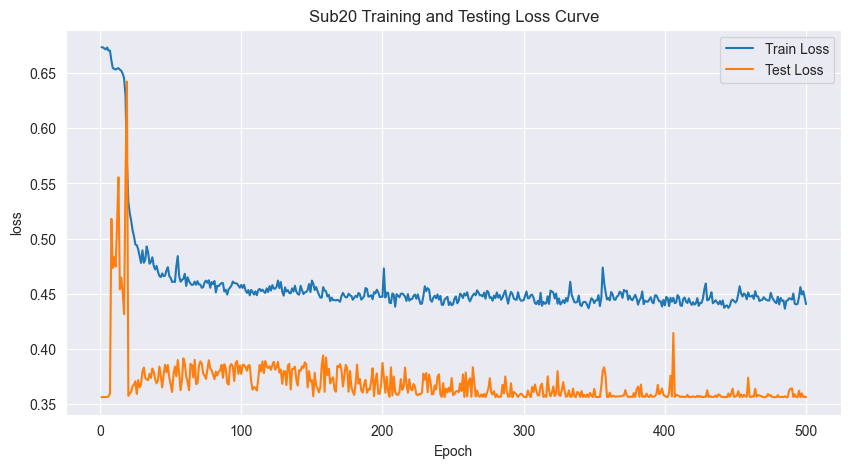

<Figure size 640x480 with 0 Axes>

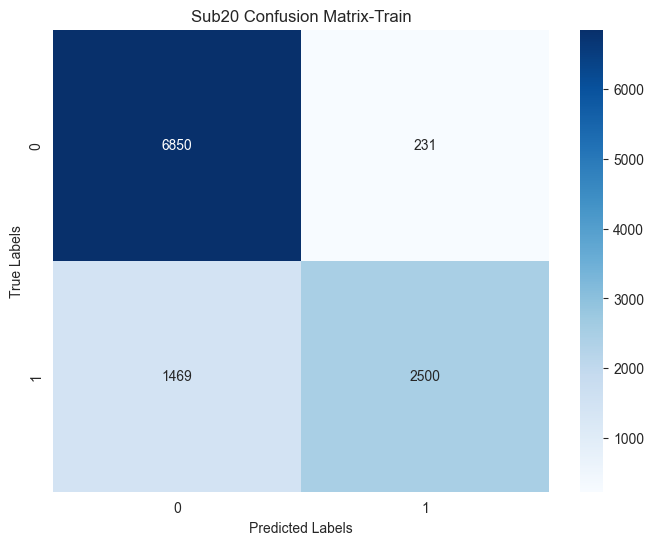

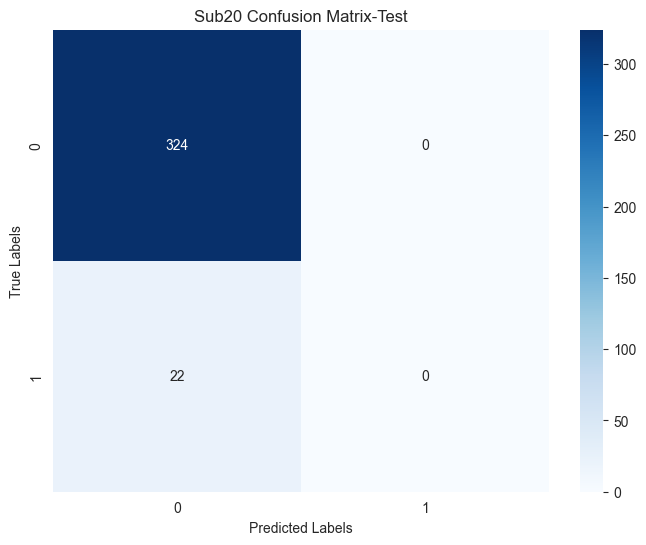

第 19 折（测试序号18）Acc: 93.64%

========== 开始第 20/22 折LOOCV（测试序号：19）==========
Fold [20/22], Epoch [1/500], Step [1/44], Loss: 0.6804
Fold [20/22], Epoch [1/500], Step [11/44], Loss: 0.6684
Fold [20/22], Epoch [1/500], Step [21/44], Loss: 0.6431
Fold [20/22], Epoch [1/500], Step [31/44], Loss: 0.6506
Fold [20/22], Epoch [1/500], Step [41/44], Loss: 0.6376
Fold [20/22], Epoch [101/500], Step [1/44], Loss: 0.4514
Fold [20/22], Epoch [101/500], Step [11/44], Loss: 0.4458
Fold [20/22], Epoch [101/500], Step [21/44], Loss: 0.4939
Fold [20/22], Epoch [101/500], Step [31/44], Loss: 0.4536
Fold [20/22], Epoch [101/500], Step [41/44], Loss: 0.4513
Fold [20/22], Epoch [201/500], Step [1/44], Loss: 0.4692
Fold [20/22], Epoch [201/500], Step [11/44], Loss: 0.4321
Fold [20/22], Epoch [201/500], Step [21/44], Loss: 0.4353
Fold [20/22], Epoch [201/500], Step [31/44], Loss: 0.4133
Fold [20/22], Epoch [201/500], Step [41/44], Loss: 0.4689
Fold [20/22], Epoch [301/500], Step [1/44], Loss: 0.4279
Fold [20/22]

<Figure size 640x480 with 0 Axes>

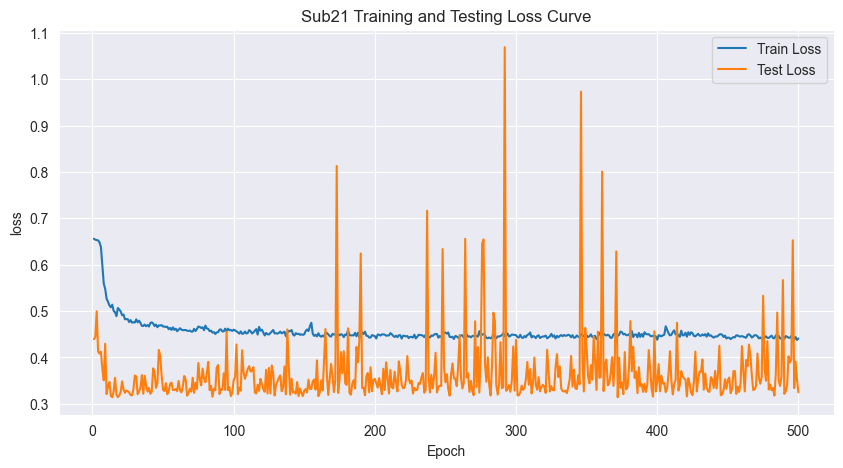

<Figure size 640x480 with 0 Axes>

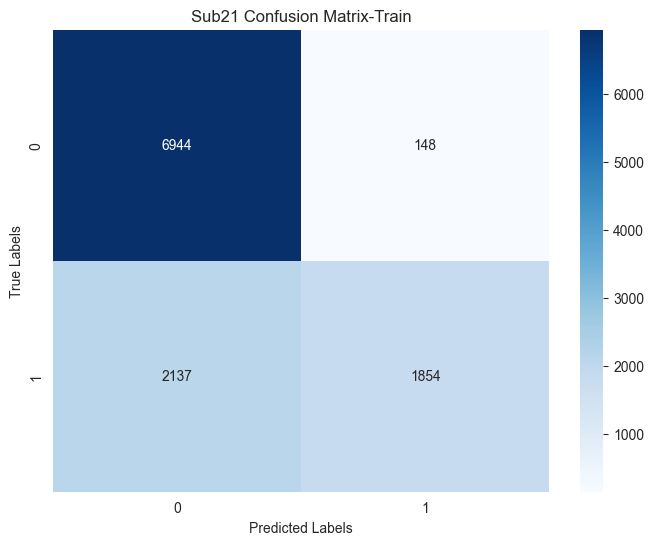

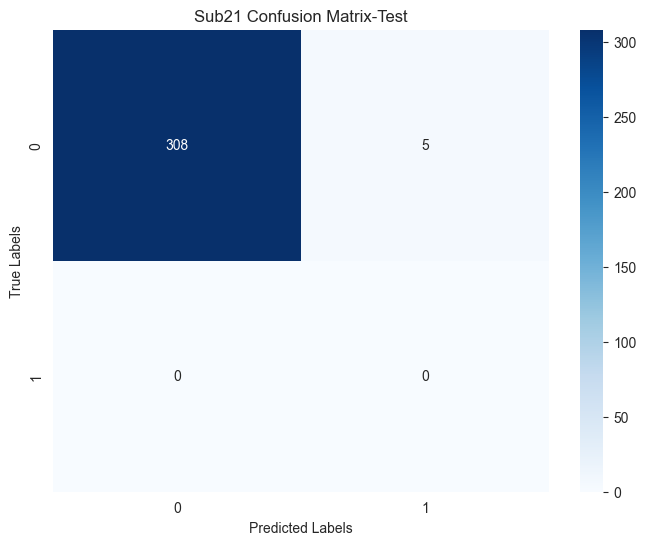

第 20 折（测试序号19）Acc: 98.40%

========== 开始第 21/22 折LOOCV（测试序号：20）==========
Fold [21/22], Epoch [1/500], Step [1/42], Loss: 0.6894
Fold [21/22], Epoch [1/500], Step [11/42], Loss: 0.6667
Fold [21/22], Epoch [1/500], Step [21/42], Loss: 0.6554
Fold [21/22], Epoch [1/500], Step [31/42], Loss: 0.6324
Fold [21/22], Epoch [1/500], Step [41/42], Loss: 0.6496
Fold [21/22], Epoch [101/500], Step [1/42], Loss: 0.4282
Fold [21/22], Epoch [101/500], Step [11/42], Loss: 0.4004
Fold [21/22], Epoch [101/500], Step [21/42], Loss: 0.4704
Fold [21/22], Epoch [101/500], Step [31/42], Loss: 0.4715
Fold [21/22], Epoch [101/500], Step [41/42], Loss: 0.4797
Fold [21/22], Epoch [201/500], Step [1/42], Loss: 0.4512
Fold [21/22], Epoch [201/500], Step [11/42], Loss: 0.4660
Fold [21/22], Epoch [201/500], Step [21/42], Loss: 0.4360
Fold [21/22], Epoch [201/500], Step [31/42], Loss: 0.4516
Fold [21/22], Epoch [201/500], Step [41/42], Loss: 0.4259
Fold [21/22], Epoch [301/500], Step [1/42], Loss: 0.4039
Fold [21/22]

<Figure size 640x480 with 0 Axes>

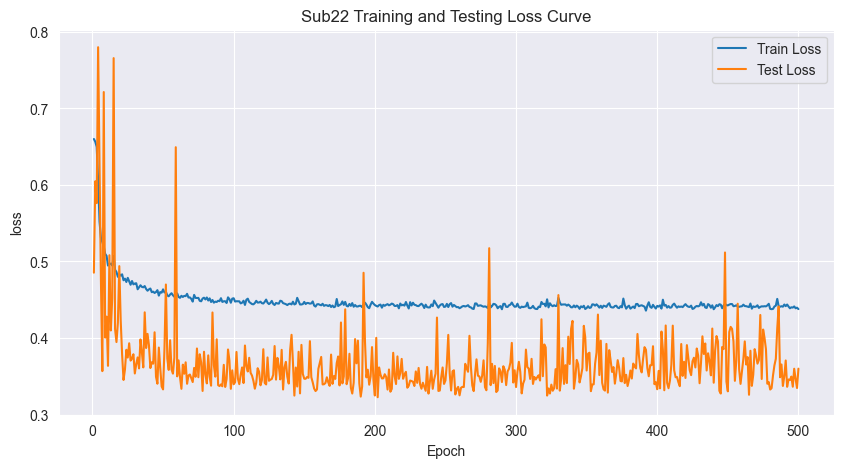

<Figure size 640x480 with 0 Axes>

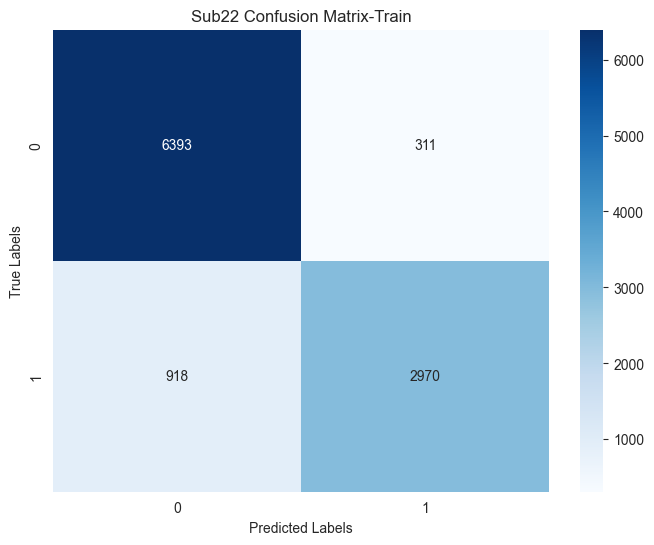

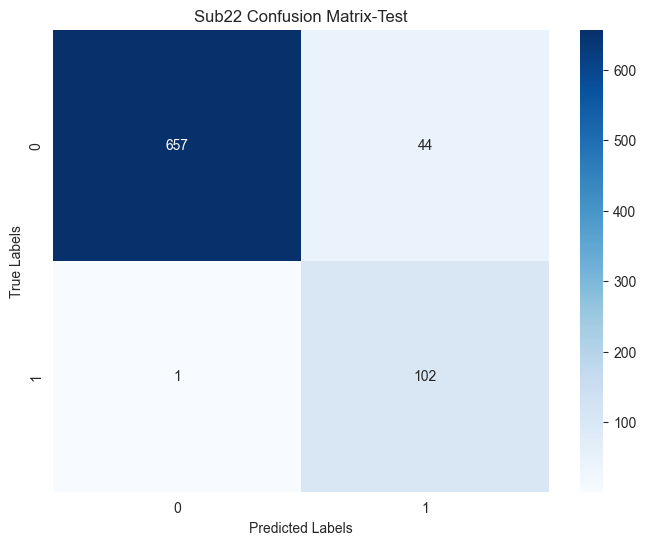

第 21 折（测试序号20）Acc: 94.40%

========== 开始第 22/22 折LOOCV（测试序号：21）==========
Fold [22/22], Epoch [1/500], Step [1/44], Loss: 0.6633
Fold [22/22], Epoch [1/500], Step [11/44], Loss: 0.6116
Fold [22/22], Epoch [1/500], Step [21/44], Loss: 0.6464
Fold [22/22], Epoch [1/500], Step [31/44], Loss: 0.6836
Fold [22/22], Epoch [1/500], Step [41/44], Loss: 0.6174
Fold [22/22], Epoch [101/500], Step [1/44], Loss: 0.4195
Fold [22/22], Epoch [101/500], Step [11/44], Loss: 0.4434
Fold [22/22], Epoch [101/500], Step [21/44], Loss: 0.4098
Fold [22/22], Epoch [101/500], Step [31/44], Loss: 0.4713
Fold [22/22], Epoch [101/500], Step [41/44], Loss: 0.4576
Fold [22/22], Epoch [201/500], Step [1/44], Loss: 0.4413
Fold [22/22], Epoch [201/500], Step [11/44], Loss: 0.4171
Fold [22/22], Epoch [201/500], Step [21/44], Loss: 0.4377
Fold [22/22], Epoch [201/500], Step [31/44], Loss: 0.4507
Fold [22/22], Epoch [201/500], Step [41/44], Loss: 0.4565
Fold [22/22], Epoch [301/500], Step [1/44], Loss: 0.4365
Fold [22/22]

<Figure size 640x480 with 0 Axes>

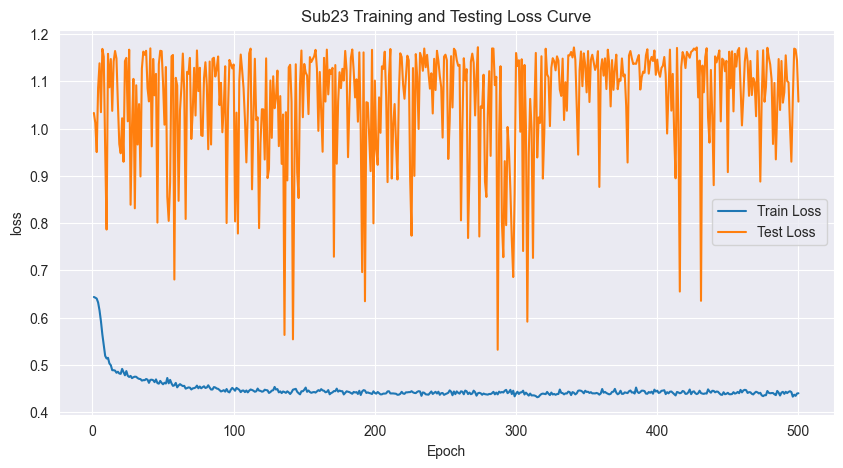

<Figure size 640x480 with 0 Axes>

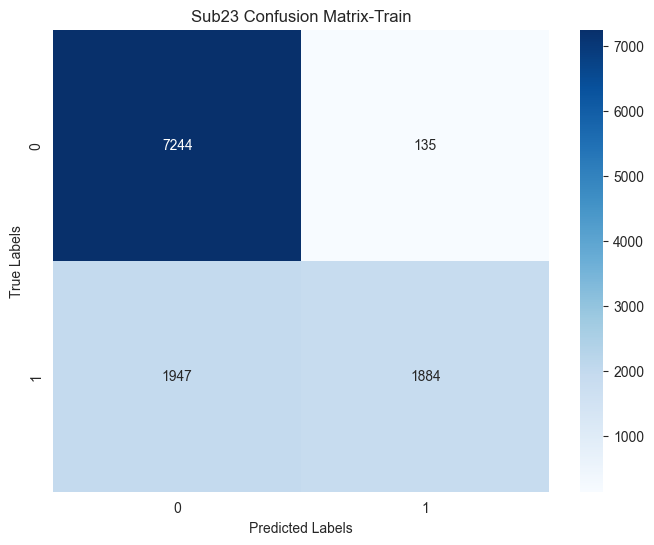

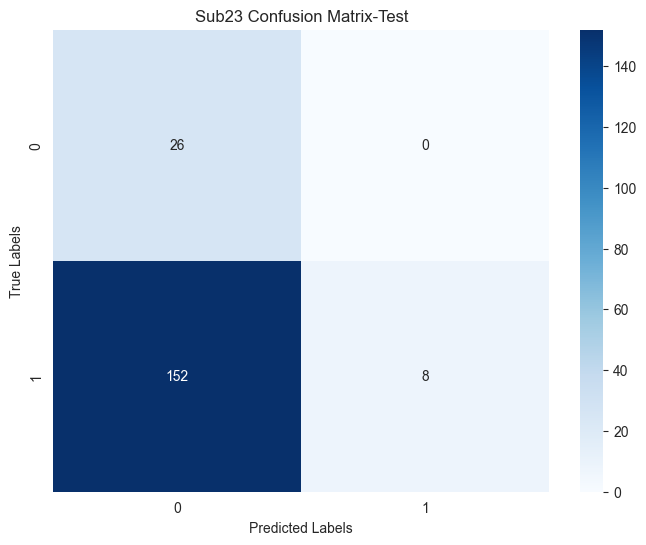

第 22 折（测试序号21）Acc: 18.28%

========== LOOCV最终结果 ==========
11折平均测试准确率: 72.42% (标准差: 21.17%)


<Figure size 640x480 with 0 Axes>

In [9]:
datas = []
test_datas = []

# 定义超参数（保持不变）
lr = 0.01
wd = 0.001
bs = 256
op = 'SGD'
dr = 0.5
epoches = 500
all_loocv_accuracies = []  # 新增：保存11次LOOCV的准确率
all_loocv_train_losses = []  # 新增：保存11次的训练损失
all_loocv_test_losses = []   # 新增：保存11次的测试损失

# 原始数据处理（保持不变）
predata = torch.Tensor(EEGsample)
label = torch.Tensor(substate).long().squeeze()
index = torch.Tensor(subindex).long().squeeze() - 1 # index是0-21
inpt = predata.reshape(-1, 1, 17, 384) # (11396,1,17,384)

# 提取所有唯一的样本序号（0-10），共11个
unique_index = torch.unique(index).numpy()
n_folds = len(unique_index)  # LOOCV的折数=11

# ====================== 核心：LOOCV循环 ======================
for fold_idx, test_idx in enumerate(unique_index):
    print(f"\n========== 开始第 {fold_idx+1}/{n_folds} 折LOOCV（测试序号：{test_idx}）==========")

    # 1. 划分本次LOOCV的训练/测试序号
    train_index_ids = [idx for idx in unique_index if idx != test_idx]  # 剩余10个作为训练
    test_index_ids = [test_idx]  # 留1个作为测试

    # 2. 生成训练/测试掩码
    train_mask = torch.zeros_like(index, dtype=torch.bool)
    for idx in train_index_ids:
        train_mask = train_mask | (index == idx)

    test_mask = torch.zeros_like(index, dtype=torch.bool)
    test_mask = test_mask | (index == test_idx)

    # === 关键修复：去掉多余维度 ===
    train_mask = train_mask.squeeze()   # 从 [1, 11396] → [11396]
    test_mask  = test_mask.squeeze()

    # 3. 拆分训练/测试数据
    train_inpt = inpt[train_mask]
    train_label = label[train_mask]
    test_inpt = inpt[test_mask]
    test_label = label[test_mask]

    # 3. 拆分训练/测试数据
    train_inpt = inpt[train_mask]
    train_label = label[train_mask]
    test_inpt = inpt[test_mask]
    test_label = label[test_mask]

    # 4. 构建数据集和DataLoader
    train_dataset = TensorDataset(train_inpt, train_label)
    test_dataset = TensorDataset(test_inpt, test_label)
    train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=bs, shuffle=False)

    # 5. 重新初始化模型/优化器（关键！LOOCV每次必须重新初始化）
    # device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    # device = torch.device("cpu")  # 强制CPU
    net = EEGViT(drop_out = dr).to(device)

    criterion = nn.CrossEntropyLoss().to(device)
    if op == 'Adam':
        optimizer = optim.Adam(net.parameters(),lr = lr,weight_decay=wd)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epoches, eta_min=0)
    else:
        optimizer = optim.SGD(net.parameters(),lr = lr,weight_decay=wd,momentum=0.9,nesterov=True)

    # 初始化本次折的损失记录
    train_losses = []
    test_losses = []

    # 6. 训练模型（和你原有训练逻辑一致）
    for epoch in range(epoches):
        net.train()
        train_loss = 0.0

        for i, (inputs, targets) in enumerate(train_loader):
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = net(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            if op == 'Adam':
                scheduler.step()

            # 打印日志（仅每100epoch+每10step）
            if epoch%100==0 and i %10==0:
                print(f'Fold [{fold_idx+1}/{n_folds}], Epoch [{epoch+1}/{epoches}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}')
            train_loss += loss.item()

        # 验证阶段
        net.eval()
        train_loss /= len(train_loader)
        train_losses.append(train_loss)
        test_losses = get_losses(test_losses, test_loader, net, device)

    # 7. 评估本次折的模型
    net.eval()
    # 获取预测结果
    all_train_targets, all_train_predictions = get_predictions(train_loader, net, device)
    all_test_targets, all_test_predictions = get_predictions(test_loader, net, device)

    # 保存本次折的损失/可视化（可选，按需求调整路径）
    sub_path = os.path.join(path, 'EEGViT', f'fold_{fold_idx+1}_testidx_{test_idx}')
    os.makedirs(sub_path, exist_ok=True)
    loss_curve(epoches, train_losses, test_losses, folder_path=sub_path, sub=fold_idx+1)
    plt.clf()
    plot_confusion_matrix(all_train_targets,all_train_predictions,all_test_targets,all_test_predictions,folder_path=sub_path, sub=fold_idx+1)
    plt.clf()

    # 计算本次折的准确率
    test_accuracy = calculate_accuracy(test_loader, net, device)
    all_loocv_accuracies.append(test_accuracy)
    print(f'第 {fold_idx+1} 折（测试序号{test_idx}）Acc: {test_accuracy:.2f}%')

    # 保存本次折的损失
    all_loocv_train_losses.append(train_losses)
    all_loocv_test_losses.append(test_losses)

    # 写入单次折的结果到报告
    with open(report_path, 'a') as f:
        f.write(f'LOOCV Fold {fold_idx+1}（测试序号{test_idx}）Acc: {test_accuracy:.2f}%\n')

# ====================== LOOCV结束：计算最终结果 ======================
# 计算11次折的平均准确率
mean_loocv_accuracy = np.mean(all_loocv_accuracies)
std_loocv_accuracy = np.std(all_loocv_accuracies)  # 标准差，评估稳定性
print(f"\n========== LOOCV最终结果 ==========")
print(f'11折平均测试准确率: {mean_loocv_accuracy:.2f}% (标准差: {std_loocv_accuracy:.2f}%)')

# 写入最终结果到报告
with open(report_path, 'a') as f:
    f.write(f'\nLOOCV 11折平均准确率: {mean_loocv_accuracy:.2f}% (标准差: {std_loocv_accuracy:.2f}%)\n')
    f.write(f'各折准确率: {[f"{acc:.2f}%" for acc in all_loocv_accuracies]}\n')